<!-- document-notebook:managed:v1 anchor=ee2440f8 source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

# Analisis Pemisahan Varian HMUG Menjadi SKU Mandiri

Notebook ini memilih sedikitnya tiga varian aktif dari SKU induk HMUG untuk dipisahkan menjadi SKU mandiri. Unit analisisnya adalah satu varian dengan agregat penjualan dan jumlah produk bulanan selama Juni–Agustus 2026. Pendekatan yang digunakan sepenuhnya deskriptif: audit kualitas data, atribusi konservatif, ranking, sensitivity analysis, leave-one-month-out, simulasi konsentrasi, dan business what-if tanpa machine learning.

**Batas bukti:** Agustus hanya tercatat sampai 28 Agustus; data tidak memuat transaksi, COGS, stok, iklan, retur, atau eksperimen pemisahan. Saved output merupakan bukti historis. Execution count tidak berurutan setelah restrukturisasi dan Cells 18–21 belum memiliki saved output, sehingga notebook perlu dijalankan ulang di Jupyter untuk menyimpan bukti eksekusi final.

## Fase 1 — Persiapan dan pemuatan data

### Cell 01: Menyiapkan lingkungan analisis

- **Tujuan Utama:** Menetapkan library, format tampilan, file sumber, dan batas metode.
- **Input:** `Dummy Brand _ PERFORMA PRODUK - JUNI sd AGUSTUS 2026.xlsx`.
- **Output:** `file_path` dan objek `excel`.
- **Validasi:** Assertion menghentikan proses jika workbook tidak ditemukan.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT untuk nama file, lima sheet, dan pernyataan tanpa machine learning.


In [1]:
# Cell 1 - Menyiapkan analisis
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

file_path = Path("Dummy Brand _ PERFORMA PRODUK - JUNI sd AGUSTUS 2026.xlsx").resolve()
assert file_path.exists(), f"File tidak ditemukan: {file_path}"

excel = pd.ExcelFile(file_path)
print("[Konteks Analisis]")
print(f"File sumber : {file_path.name}")
print(f"Jumlah sheet: {len(excel.sheet_names)}")
print("Metode      : Analisis deskriptif dan ranking, tanpa machine learning")

[Konteks Analisis]
File sumber : Dummy Brand _ PERFORMA PRODUK - JUNI sd AGUSTUS 2026.xlsx
Jumlah sheet: 5
Metode      : Analisis deskriptif dan ranking, tanpa machine learning


<!-- document-notebook:managed:v1 anchor=89ff88ea source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

### Cell 02: Memuat dan menstandardisasi tabel

- **Tujuan Utama:** Membentuk tabel toko, SKU induk, dan varian dengan nama kolom serta tipe numerik yang konsisten.
- **Input:** Lima sheet workbook dan `file_path` dari Cell 01.
- **Proses/Metode:** Membaca header dua tingkat, membuang baris tanpa kunci, mengonversi metrik numerik, dan menggabungkan tiga sheet varian.
- **Output:** `store`, `parent`, `variants`, `store_total`, serta daftar kolom bulanan.
- **Temuan Utama:** Saved output melaporkan 2.830 SKU induk, 110 baris varian, dan total penjualan Rp816.449.942.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [2]:
# Cell 2 - Memuat dan menstandardisasi data
parent_columns = [
    "rank", "sku_induk",
    "sales_jun", "share_jun", "units_jun",
    "sales_jul", "share_jul", "units_jul",
    "sales_aug", "share_aug", "units_aug",
    "sales_total", "share_total", "units_total"
]
variant_columns = [
    "rank", "sku_induk", "varian", "status",
    "sales_jun", "share_jun", "units_jun",
    "sales_jul", "share_jul", "units_jul",
    "sales_aug", "share_aug", "units_aug",
    "sales_total", "share_total", "units_total"
]
numeric_columns = [
    "sales_jun", "share_jun", "units_jun",
    "sales_jul", "share_jul", "units_jul",
    "sales_aug", "share_aug", "units_aug",
    "sales_total", "share_total", "units_total"
]

store = pd.read_excel(file_path, sheet_name="1. Total Penjualan Toko")

parent = pd.read_excel(
    file_path,
    sheet_name="2. Kontribusi SKU Induk",
    header=1
)
parent.columns = parent_columns
parent = parent.dropna(subset=["sku_induk"]).copy()
parent[numeric_columns] = parent[numeric_columns].apply(pd.to_numeric, errors="coerce")

variant_sheets = [
    "3. Top 1 SKU Induk - Variasi HM",
    "4. Top 2 SKU Induk - Variasi HA",
    "5. Top 3 SKU Induk - Variasi HA"
]
variant_frames = []
for sheet_name in variant_sheets:
    frame = pd.read_excel(file_path, sheet_name=sheet_name, header=1)
    frame.columns = variant_columns
    frame = frame.dropna(subset=["sku_induk", "varian"]).copy()
    frame[numeric_columns] = frame[numeric_columns].apply(pd.to_numeric, errors="coerce")
    variant_frames.append(frame)

variants = pd.concat(variant_frames, ignore_index=True)
store_total = parent["sales_total"].sum()
reported_store_total = pd.to_numeric(store.iloc[0]["Total"], errors="raise")

print("[Data yang Dimuat]")
print(f"SKU induk          : {len(parent):,} baris")
print(f"Varian             : {len(variants):,} baris")
print(f"Periode            : Juni–Agustus 2026")
print(f"Total penjualan    : Rp{store_total:,.0f}")
print(f"Status varian      : {', '.join(sorted(variants['status'].unique()))}")

[Data yang Dimuat]
SKU induk          : 2,830 baris
Varian             : 110 baris
Periode            : Juni–Agustus 2026
Total penjualan    : Rp816,449,942
Status varian      : Dihapus, Normal


<!-- document-notebook:managed:v1 anchor=1b32a078 source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

## Fase 2 — Audit kualitas dan rekonsiliasi

### Cell 03: Mengaudit kualitas data dasar

- **Tujuan Utama:** Memastikan kunci, nilai, total bulanan, kontribusi, dan relasi induk–varian layak digunakan.
- **Proses/Metode:** Memeriksa missing value, nilai negatif, duplikasi kunci, status, penjumlahan bulanan, dan perhitungan share.
- **Output:** `audit`, `raw_reconciliation`, dan `raw_mismatches`.
- **Temuan Utama:** Saved output menunjukkan seluruh pemeriksaan blocking lulus; satu peringatan tersisa karena total mentah varian HMUG tidak cocok dengan induknya.
- **Downstream Impact:** Peringatan tersebut diselidiki pada Cell 04 sebelum omzet dipakai untuk ranking.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [3]:
# Cell 3 - Mengaudit kualitas data dasar
sales_months = ["sales_jun", "sales_jul", "sales_aug"]
unit_months = ["units_jun", "units_jul", "units_aug"]
allowed_statuses = {"Normal", "Dihapus"}

parent_share_ok = np.isclose(
    parent["share_total"],
    parent["sales_total"] / store_total,
    atol=1e-9
)
variant_with_parent = variants.merge(
    parent[["sku_induk", "sales_total"]].rename(columns={"sales_total": "parent_sales_total"}),
    on="sku_induk",
    how="left",
    validate="many_to_one"
)
variant_share_ok = np.isclose(
    variant_with_parent["share_total"],
    variant_with_parent["sales_total"] / variant_with_parent["parent_sales_total"],
    atol=1e-9
)

raw_variant_totals = (
    variants.groupby("sku_induk", as_index=False)["sales_total"]
    .sum()
    .rename(columns={"sales_total": "sales_total_varian"})
)
raw_reconciliation = (
    parent[["sku_induk", "sales_total"]]
    .merge(raw_variant_totals, on="sku_induk", how="inner", validate="one_to_one")
    .rename(columns={"sales_total": "sales_total_induk"})
)
raw_reconciliation["selisih"] = (
    raw_reconciliation["sales_total_varian"] - raw_reconciliation["sales_total_induk"]
)
raw_mismatches = raw_reconciliation.loc[~np.isclose(raw_reconciliation["selisih"], 0, atol=1)]

audit = pd.DataFrame([
    ["Total SKU induk cocok dengan total toko", int(store_total != reported_store_total), "Blocking"],
    ["Nilai kosong pada kunci dan metrik utama", int(
        parent[["sku_induk", "sales_total", "units_total"]].isna().sum().sum()
        + variants[["sku_induk", "varian", "status", "sales_total", "units_total"]].isna().sum().sum()
    ), "Blocking"],
    ["Nilai penjualan atau produk negatif", int(
        parent[sales_months + unit_months + ["sales_total", "units_total"]].lt(0).sum().sum()
        + variants[sales_months + unit_months + ["sales_total", "units_total"]].lt(0).sum().sum()
    ), "Blocking"],
    ["Kunci SKU induk duplikat", int(parent["sku_induk"].duplicated().sum()), "Blocking"],
    ["Kunci SKU induk-varian duplikat", int(variants.duplicated(["sku_induk", "varian"]).sum()), "Blocking"],
    ["Status di luar kategori yang diizinkan", len(set(variants["status"]) - allowed_statuses), "Blocking"],
    ["Total penjualan SKU induk tidak sama dengan jumlah bulanan", int((~np.isclose(parent["sales_total"], parent[sales_months].sum(axis=1), atol=1)).sum()), "Blocking"],
    ["Total produk SKU induk tidak sama dengan jumlah bulanan", int((~np.isclose(parent["units_total"], parent[unit_months].sum(axis=1), atol=0)).sum()), "Blocking"],
    ["Total penjualan varian tidak sama dengan jumlah bulanan", int((~np.isclose(variants["sales_total"], variants[sales_months].sum(axis=1), atol=1)).sum()), "Blocking"],
    ["Total produk varian tidak sama dengan jumlah bulanan", int((~np.isclose(variants["units_total"], variants[unit_months].sum(axis=1), atol=0)).sum()), "Blocking"],
    ["Kontribusi SKU induk salah hitung", int((~parent_share_ok).sum()), "Blocking"],
    ["Kontribusi varian salah hitung", int((~variant_share_ok).sum()), "Blocking"],
    ["Total varian mentah tidak cocok dengan induk", len(raw_mismatches), "Peringatan ditangani"]
], columns=["pemeriksaan", "jumlah_masalah", "jenis"])
audit["status"] = np.select(
    [audit["jumlah_masalah"].eq(0), audit["jenis"].eq("Blocking")],
    ["LULUS", "GAGAL"],
    default="PERINGATAN"
)

print("[Audit Kualitas Data]")
display(audit)
print("\n[Rekonsiliasi yang Perlu Diinvestigasi]")
display(raw_mismatches.style.format({
    "sales_total_induk": "Rp{:,.0f}",
    "sales_total_varian": "Rp{:,.0f}",
    "selisih": "Rp{:,.0f}"
}))

[Audit Kualitas Data]


,pemeriksaan,jumlah_masalah,jenis,status
0,Total SKU induk cocok dengan total toko,0,Blocking,LULUS
1,Nilai kosong pada kunci dan metrik utama,0,Blocking,LULUS
2,Nilai penjualan atau produk negatif,0,Blocking,LULUS
3,Kunci SKU induk duplikat,0,Blocking,LULUS
4,Kunci SKU induk-varian duplikat,0,Blocking,LULUS
5,Status di luar kategori yang diizinkan,0,Blocking,LULUS
6,Total penjualan SKU induk tidak sama dengan jumlah bulanan,0,Blocking,LULUS
7,Total produk SKU induk tidak sama dengan jumlah bulanan,0,Blocking,LULUS
8,Total penjualan varian tidak sama dengan jumlah bulanan,0,Blocking,LULUS
9,Total produk varian tidak sama dengan jumlah bulanan,0,Blocking,LULUS



[Rekonsiliasi yang Perlu Diinvestigasi]


,sku_induk,sales_total_induk,sales_total_varian,selisih
0,HMUG,"Rp177,705,421","Rp259,906,900","Rp82,201,479"


<!-- document-notebook:managed:v1 anchor=e2595e56 source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

### Cell 04: Membuktikan sumber selisih HMUG

- **Tujuan Utama:** Menentukan mengapa jumlah omzet varian HMUG lebih besar daripada omzet induknya.
- **Proses/Metode:** Mengubah data HMUG menjadi format bulanan panjang, menandai pasangan penjualan–produk positif yang muncul berulang, lalu menghitung ulang setiap pasangan unik satu kali.
- **Output:** `hmug_long`, `duplicate_groups`, dan `hmug_reconciliation`.
- **Temuan Utama:** Saved output menunjukkan deduplikasi pasangan identik merekonsiliasi Juni, Juli, dan Agustus ke total induk dengan selisih Rp0.
- **Batasan / Open Issue:** Deduplikasi membuktikan pencatatan berulang, tetapi tidak mengidentifikasi varian pemilik omzet yang sebenarnya.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [4]:
# Cell 4 - Membuktikan penyebab selisih HMUG
hmug_variants = variants.loc[variants["sku_induk"].eq("HMUG")].copy()
hmug_parent = parent.loc[parent["sku_induk"].eq("HMUG")].iloc[0]
month_map = {
    "Juni": ("sales_jun", "units_jun"),
    "Juli": ("sales_jul", "units_jul"),
    "Agustus": ("sales_aug", "units_aug")
}

hmug_long = pd.concat([
    hmug_variants[["varian", "status", sales_col, units_col]]
    .rename(columns={sales_col: "penjualan", units_col: "produk"})
    .assign(bulan=month)
    for month, (sales_col, units_col) in month_map.items()
], ignore_index=True)

hmug_long["jumlah_kemunculan"] = (
    hmug_long.groupby(["bulan", "penjualan", "produk"])["varian"].transform("size")
)
hmug_long["ambigu"] = hmug_long["penjualan"].gt(0) & hmug_long["jumlah_kemunculan"].gt(1)

duplicate_groups = (
    hmug_long.loc[hmug_long["ambigu"]]
    .groupby(["bulan", "penjualan", "produk"], as_index=False)
    .agg(
        jumlah_kemunculan=("varian", "size"),
        daftar_varian=("varian", lambda values: ", ".join(values))
    )
)

reconciliation_rows = []
for month, (sales_col, _) in month_map.items():
    monthly = hmug_long.loc[hmug_long["bulan"].eq(month) & hmug_long["penjualan"].gt(0)]
    deduplicated = monthly.drop_duplicates(["penjualan", "produk"])
    parent_value = hmug_parent[sales_col]
    reconciliation_rows.append({
        "bulan": month,
        "total_induk": parent_value,
        "total_varian_mentah": monthly["penjualan"].sum(),
        "total_setelah_dedup": deduplicated["penjualan"].sum(),
        "selisih_setelah_dedup": deduplicated["penjualan"].sum() - parent_value
    })

hmug_reconciliation = pd.DataFrame(reconciliation_rows)

print("[Bukti Duplikasi Angka Bulanan HMUG]")
display(hmug_reconciliation.style.format({
    "total_induk": "Rp{:,.0f}",
    "total_varian_mentah": "Rp{:,.0f}",
    "total_setelah_dedup": "Rp{:,.0f}",
    "selisih_setelah_dedup": "Rp{:,.0f}"
}))
print("\n[Kelompok Angka Berulang]")
display(duplicate_groups.style.format({"penjualan": "Rp{:,.0f}", "produk": "{:,.0f}"}))

[Bukti Duplikasi Angka Bulanan HMUG]


,bulan,total_induk,total_varian_mentah,total_setelah_dedup,selisih_setelah_dedup
0,Juni,"Rp66,119,528","Rp126,640,238","Rp66,119,528",Rp0
1,Juli,"Rp39,296,123","Rp51,192,926","Rp39,296,123",Rp0
2,Agustus,"Rp72,289,770","Rp82,073,736","Rp72,289,770",Rp0



[Kelompok Angka Berulang]


,bulan,penjualan,produk,jumlah_kemunculan,daftar_varian
0,Agustus,"Rp3,261,322",16,4,"VAR-A02,COL-01, VAR-A04,COL-01, VAR-D01,COL-02, VAR-B02,COL-02"
1,Juli,"Rp3,965,601",21,4,"VAR-A02,COL-01, VAR-A03,COL-01, VAR-D01,COL-02, VAR-C02,COL-03"
2,Juni,"Rp5,164,257",28,4,"VAR-D01,COL-02, VAR-C02,COL-03, VAR-B02,COL-02, VAR-C04,COL-03"
3,Juni,"Rp15,009,313",82,4,"VAR-A02,COL-01, VAR-A03,COL-01, VAR-A04,COL-01, VAR-B01,COL-02"


<!-- document-notebook:managed:v1 anchor=e0fd74db source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

### Cell 05: Mengaudit kelengkapan periode

- **Tujuan Utama:** Mencegah perbandingan langsung antara bulan penuh dan Agustus yang masih parsial.
- **Proses/Metode:** Menghitung cakupan hari, rata-rata penjualan harian, ekuivalen 30 hari, dan run-rate berdasarkan kalender bulan.
- **Output:** `period_audit` dan indikator perubahan tercatat serta run-rate.
- **Temuan Utama:** Saved output melaporkan omzet Juni–Agustus tercatat turun 16,6%, tetapi Agustus baru 28 dari 31 hari. Run-rate harian Agustus 5,4% di atas Juli dan run-rate satu bulannya Rp278.127.783.
- **Batasan / Open Issue:** Run-rate mengasumsikan laju harian tetap; ini normalisasi deskriptif, bukan forecast.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [5]:
# Cell 5 - Mengaudit kelengkapan periode dan run-rate harian
period_audit = pd.DataFrame({
    "bulan": ["Juni", "Juli", "Agustus"],
    "kolom_penjualan": ["sales_jun", "sales_jul", "sales_aug"],
    "data_sampai": pd.to_datetime(["2026-06-30", "2026-07-31", "2026-08-28"])
})

period_audit["hari_tercatat"] = period_audit["data_sampai"].dt.day
period_audit["hari_dalam_bulan"] = (
    period_audit["data_sampai"] + pd.offsets.MonthEnd(0)
).dt.day
period_audit["cakupan_periode"] = (
    period_audit["hari_tercatat"] / period_audit["hari_dalam_bulan"]
)

monthly_sales = {
    column: parent[column].sum()
    for column in period_audit["kolom_penjualan"]
}
period_audit["penjualan_tercatat"] = (
    period_audit["kolom_penjualan"].map(monthly_sales)
)
period_audit["rata_rata_per_hari"] = (
    period_audit["penjualan_tercatat"] / period_audit["hari_tercatat"]
)
period_audit["setara_30_hari"] = (
    period_audit["rata_rata_per_hari"] * 30
)
period_audit["run_rate_satu_bulan"] = (
    period_audit["rata_rata_per_hari"] * period_audit["hari_dalam_bulan"]
)
period_audit["perubahan_angka_tercatat"] = (
    period_audit["penjualan_tercatat"].pct_change()
)
period_audit["perubahan_run_rate_harian"] = (
    period_audit["rata_rata_per_hari"].pct_change()
)
period_audit["status_periode"] = np.where(
    period_audit["hari_tercatat"].eq(period_audit["hari_dalam_bulan"]),
    "Bulan penuh",
    "Bulan parsial"
)

reported_store_monthly = pd.to_numeric(
    store.iloc[0][["Juni 2026", "Juli 2026", "Agustus 2026"]],
    errors="raise"
).to_numpy()
assert np.allclose(
    period_audit["penjualan_tercatat"],
    reported_store_monthly,
    atol=1
), "Total bulanan SKU induk tidak cocok dengan ringkasan toko."

june = period_audit.iloc[0]
july = period_audit.iloc[1]
august = period_audit.iloc[2]

raw_june_to_august = (
    august["penjualan_tercatat"] / june["penjualan_tercatat"] - 1
)
august_daily_vs_july = (
    august["rata_rata_per_hari"] / july["rata_rata_per_hari"] - 1
)
august_run_rate_vs_june = (
    august["run_rate_satu_bulan"] / june["penjualan_tercatat"] - 1
)

print("[Audit Kelengkapan Periode]")
display(
    period_audit[[
        "bulan",
        "data_sampai",
        "status_periode",
        "hari_tercatat",
        "hari_dalam_bulan",
        "cakupan_periode",
        "penjualan_tercatat",
        "rata_rata_per_hari",
        "setara_30_hari",
        "run_rate_satu_bulan",
        "perubahan_angka_tercatat",
        "perubahan_run_rate_harian"
    ]].style.format({
        "data_sampai": lambda value: value.strftime("%d %B %Y"),
        "cakupan_periode": "{:.1%}",
        "penjualan_tercatat": "Rp{:,.0f}",
        "rata_rata_per_hari": "Rp{:,.0f}",
        "setara_30_hari": "Rp{:,.0f}",
        "run_rate_satu_bulan": "Rp{:,.0f}",
        "perubahan_angka_tercatat": "{:+.1%}",
        "perubahan_run_rate_harian": "{:+.1%}"
    }, na_rep="-")
)

print("\n[Interpretasi]")
print(
    f"Angka tercatat Juni–Agustus berubah {raw_june_to_august:+.1%}, "
    "tetapi Agustus baru mencakup "
    f"{august['hari_tercatat']:.0f} dari {august['hari_dalam_bulan']:.0f} hari."
)
print(
    f"Rata-rata penjualan harian Agustus {august_daily_vs_july:+.1%} "
    "dibandingkan Juli."
)
print(
    f"Jika laju harian Agustus bertahan, run-rate satu bulan menjadi "
    f"Rp{august['run_rate_satu_bulan']:,.0f}, "
    f"atau {august_run_rate_vs_june:+.1%} dibandingkan Juni."
)
print(
    "Catatan: run-rate adalah normalisasi deskriptif dengan asumsi laju harian tetap, "
    "bukan forecast atau bukti bahwa tren akan berlanjut."
)

[Audit Kelengkapan Periode]


,bulan,data_sampai,status_periode,hari_tercatat,hari_dalam_bulan,cakupan_periode,penjualan_tercatat,rata_rata_per_hari,setara_30_hari,run_rate_satu_bulan,perubahan_angka_tercatat,perubahan_run_rate_harian
0,Juni,30 June 2026,Bulan penuh,30,30,100.0%,"Rp301,366,853","Rp10,045,562","Rp301,366,853","Rp301,366,853",-,-
1,Juli,31 July 2026,Bulan penuh,31,31,100.0%,"Rp263,870,898","Rp8,511,964","Rp255,358,934","Rp263,870,898",-12.4%,-15.3%
2,Agustus,28 August 2026,Bulan parsial,28,31,90.3%,"Rp251,212,191","Rp8,971,864","Rp269,155,919","Rp278,127,783",-4.8%,+5.4%



[Interpretasi]
Angka tercatat Juni–Agustus berubah -16.6%, tetapi Agustus baru mencakup 28 dari 31 hari.
Rata-rata penjualan harian Agustus +5.4% dibandingkan Juli.
Jika laju harian Agustus bertahan, run-rate satu bulan menjadi Rp278,127,783, atau -7.7% dibandingkan Juni.
Catatan: run-rate adalah normalisasi deskriptif dengan asumsi laju harian tetap, bukan forecast atau bukti bahwa tren akan berlanjut.


<!-- document-notebook:managed:v1 anchor=28c6ac6c source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

## Fase 3 — Seleksi kandidat dan robustness

### Cell 06: Membuat ranking konservatif

- **Tujuan Utama:** Membentuk kandidat yang dapat dipertanggungjawabkan tanpa mengarang atribusi omzet ambigu.
- **Proses/Metode:** Omzet berulang diberi nilai terkonfirmasi nol. Kandidat harus berstatus `Normal`, memiliki atribusi penuh, dan terjual pada ketiga bulan; kandidat kemudian diranking berdasarkan omzet, produk, median bulanan, dan bulan terlemah.
- **Output:** `eligible`, `decision_table`, `selected_variants`, dan `selected_names`.
- **Keputusan:** Saved output memilih `VAR-A01,COL-01`, `VAR-C01,COL-03`, dan `VAR-D02,COL-01`.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [6]:
# Cell 6 - Membuat ranking konservatif yang dapat diaudit
hmug_scored = hmug_long.copy()
hmug_scored["penjualan_terkonfirmasi"] = hmug_scored["penjualan"].where(~hmug_scored["ambigu"], 0)
hmug_scored["penjualan_ambigu"] = hmug_scored["penjualan"].where(hmug_scored["ambigu"], 0)
hmug_scored["produk_terkonfirmasi"] = hmug_scored["produk"].where(~hmug_scored["ambigu"], 0)

candidate_summary = (
    hmug_scored.groupby(["varian", "status"], as_index=False)
    .agg(
        penjualan_dilaporkan=("penjualan", "sum"),
        penjualan_terkonfirmasi=("penjualan_terkonfirmasi", "sum"),
        penjualan_ambigu=("penjualan_ambigu", "sum"),
        produk_terkonfirmasi=("produk_terkonfirmasi", "sum"),
        bulan_terkonfirmasi=("penjualan_terkonfirmasi", lambda values: values.gt(0).sum())
    )
)
candidate_summary["porsi_terkonfirmasi"] = (
    candidate_summary["penjualan_terkonfirmasi"]
    .div(candidate_summary["penjualan_dilaporkan"])
    .fillna(0)
)

monthly_confirmed = (
    hmug_scored.pivot(index="varian", columns="bulan", values="penjualan_terkonfirmasi")
    .reindex(columns=["Juni", "Juli", "Agustus"])
    .fillna(0)
)
eligible = (
    candidate_summary.loc[
        candidate_summary["status"].eq("Normal")
        & candidate_summary["porsi_terkonfirmasi"].ge(0.999999)
        & candidate_summary["bulan_terkonfirmasi"].eq(3)
    ]
    .set_index("varian")
    .join(monthly_confirmed)
)
eligible["median_bulanan"] = eligible[["Juni", "Juli", "Agustus"]].median(axis=1)
eligible["bulan_terlemah"] = eligible[["Juni", "Juli", "Agustus"]].min(axis=1)

rank_metrics = {
    "penjualan_terkonfirmasi": "rank_omzet",
    "produk_terkonfirmasi": "rank_produk",
    "median_bulanan": "rank_median",
    "bulan_terlemah": "rank_bulan_terlemah"
}
for metric, rank_name in rank_metrics.items():
    eligible[rank_name] = eligible[metric].rank(method="min", ascending=False).astype(int)

decision_table = eligible.reset_index().sort_values("rank_omzet").reset_index(drop=True)
selected_variants = decision_table.head(3).copy()
selected_variants["rekomendasi"] = "Pisahkan menjadi SKU tunggal"
selected_names = selected_variants["varian"].tolist()

print("[Kandidat yang Lolos Syarat]")
display(decision_table[[
    "varian", "penjualan_terkonfirmasi", "produk_terkonfirmasi",
    "median_bulanan", "bulan_terlemah", "rank_omzet", "rank_produk",
    "rank_median", "rank_bulan_terlemah"
]].style.format({
    "penjualan_terkonfirmasi": "Rp{:,.0f}",
    "produk_terkonfirmasi": "{:,.0f}",
    "median_bulanan": "Rp{:,.0f}",
    "bulan_terlemah": "Rp{:,.0f}"
}))
print("\n[Tiga Rekomendasi Awal]")
display(selected_variants[[
    "varian", "penjualan_terkonfirmasi", "produk_terkonfirmasi", "rekomendasi"
]].style.format({"penjualan_terkonfirmasi": "Rp{:,.0f}", "produk_terkonfirmasi": "{:,.0f}"}))

[Kandidat yang Lolos Syarat]


,varian,penjualan_terkonfirmasi,produk_terkonfirmasi,median_bulanan,bulan_terlemah,rank_omzet,rank_produk,rank_median,rank_bulan_terlemah
0,"VAR-A01,COL-01","Rp94,297,119",629,"Rp22,056,710","Rp21,268,122",1,1,1,1
1,"VAR-C01,COL-03","Rp12,827,862",71,"Rp4,333,317","Rp2,885,443",2,2,2,2
2,"VAR-D02,COL-01","Rp8,446,915",44,"Rp2,986,079","Rp2,349,067",3,3,3,3
3,"VAR-B03,COL-02","Rp6,409,746",36,"Rp2,652,592","Rp164,900",4,4,4,8
4,"VAR-C03,COL-03","Rp6,177,562",34,"Rp2,262,888","Rp533,461",5,5,5,5
5,"VAR-B04,COL-02","Rp3,710,672",23,"Rp1,223,421","Rp953,794",6,6,6,4
6,"VAR-D02,COL-03","Rp1,921,798",12,"Rp360,143","Rp330,164",7,7,8,6
7,"VAR-A04,COL-03","Rp1,822,302",11,"Rp717,100","Rp184,900",8,8,7,7



[Tiga Rekomendasi Awal]


,varian,penjualan_terkonfirmasi,produk_terkonfirmasi,rekomendasi
0,"VAR-A01,COL-01","Rp94,297,119",629,Pisahkan menjadi SKU tunggal
1,"VAR-C01,COL-03","Rp12,827,862",71,Pisahkan menjadi SKU tunggal
2,"VAR-D02,COL-01","Rp8,446,915",44,Pisahkan menjadi SKU tunggal


<!-- document-notebook:managed:v1 anchor=d54ec66d source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

### Cell 07: Menguji tiga perlakuan omzet ambigu

- **Tujuan Utama:** Menilai apakah keputusan berubah ketika omzet berulang diperlakukan dengan asumsi berbeda.
- **Proses/Metode:** Membandingkan skenario konservatif, bagi rata ke seluruh varian terkait, dan bagi rata hanya ke varian aktif.
- **Output:** `scenario_ranking`, `scenario_top3`, dan `selection_frequency`.
- **Temuan Utama:** Saved output menunjukkan A01 dan C01 masuk tiga besar pada 3/3 skenario, D02 pada 2/3, dan A02 hanya pada skenario pembagian ke varian aktif.
- **Alasan Metodologis:** Sensitivity analysis membuat konsekuensi asumsi atribusi terlihat tanpa mengklaim satu pembagian sebagai kebenaran.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [7]:
# Cell 7 - Menguji sensitivitas perlakuan omzet ambigu
sensitivity = hmug_scored.copy()
group_keys = ["bulan", "penjualan", "produk"]
sensitivity["jumlah_semua_varian"] = sensitivity.groupby(group_keys)["varian"].transform("size")
sensitivity["jumlah_varian_normal"] = (
    sensitivity.groupby(group_keys)["status"].transform(lambda values: values.eq("Normal").sum())
)
sensitivity["skor_konservatif"] = sensitivity["penjualan_terkonfirmasi"].astype(float)
sensitivity["skor_bagi_rata_semua"] = np.where(
    sensitivity["ambigu"],
    sensitivity["penjualan"] / sensitivity["jumlah_semua_varian"],
    sensitivity["penjualan"]
).astype(float)
sensitivity["skor_bagi_rata_aktif"] = np.where(
    sensitivity["ambigu"] & sensitivity["status"].eq("Normal"),
    sensitivity["penjualan"] / sensitivity["jumlah_varian_normal"].replace(0, np.nan),
    np.where(sensitivity["ambigu"], 0, sensitivity["penjualan"])
).astype(float)

scenario_columns = {
    "Konservatif": "skor_konservatif",
    "Bagi rata semua varian": "skor_bagi_rata_semua",
    "Bagi rata varian aktif": "skor_bagi_rata_aktif"
}
scenario_results = []
for scenario, score_column in scenario_columns.items():
    ranking = (
        sensitivity.groupby(["varian", "status"], as_index=False)
        .agg(
            skor_penjualan=(score_column, "sum"),
            bulan_dengan_penjualan=(score_column, lambda values: values.gt(0).sum())
        )
    )
    ranking = (
        ranking.loc[ranking["status"].eq("Normal") & ranking["bulan_dengan_penjualan"].eq(3)]
        .sort_values("skor_penjualan", ascending=False)
        .reset_index(drop=True)
    )
    ranking["ranking"] = ranking.index + 1
    ranking["skenario"] = scenario
    scenario_results.append(ranking)

scenario_ranking = pd.concat(scenario_results, ignore_index=True)
scenario_top3 = scenario_ranking.loc[scenario_ranking["ranking"].le(3)].copy()
selection_frequency = (
    scenario_top3.groupby("varian", as_index=False)
    .agg(
        jumlah_masuk_tiga_besar=("skenario", "nunique"),
        skenario=("skenario", lambda values: ", ".join(values))
    )
    .sort_values(["jumlah_masuk_tiga_besar", "varian"], ascending=[False, True])
)

print("[Tiga Besar pada Setiap Skenario]")
display(scenario_top3[["skenario", "ranking", "varian", "skor_penjualan"]].style.format({
    "skor_penjualan": "Rp{:,.0f}"
}))
print("\n[Ketahanan Kandidat]")
display(selection_frequency)

[Tiga Besar pada Setiap Skenario]


,skenario,ranking,varian,skor_penjualan
0,Konservatif,1,"VAR-A01,COL-01","Rp94,297,119"
1,Konservatif,2,"VAR-C01,COL-03","Rp12,827,862"
2,Konservatif,3,"VAR-D02,COL-01","Rp8,446,915"
8,Bagi rata semua varian,1,"VAR-A01,COL-01","Rp94,297,119"
9,Bagi rata semua varian,2,"VAR-C01,COL-03","Rp12,827,862"
10,Bagi rata semua varian,3,"VAR-D02,COL-01","Rp8,446,915"
18,Bagi rata varian aktif,1,"VAR-A01,COL-01","Rp94,297,119"
19,Bagi rata varian aktif,2,"VAR-C01,COL-03","Rp12,827,862"
20,Bagi rata varian aktif,3,"VAR-A02,COL-01","Rp10,302,788"



[Ketahanan Kandidat]


,varian,jumlah_masuk_tiga_besar,skenario
0,"VAR-A01,COL-01",3,"Konservatif, Bagi rata semua varian, Bagi rata varian aktif"
2,"VAR-C01,COL-03",3,"Konservatif, Bagi rata semua varian, Bagi rata varian aktif"
3,"VAR-D02,COL-01",2,"Konservatif, Bagi rata semua varian"
1,"VAR-A02,COL-01",1,Bagi rata varian aktif


<!-- document-notebook:managed:v1 anchor=af70cd5c source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

### Cell 08: Menjelaskan pilihan kandidat ketiga

- **Tujuan Utama:** Membandingkan D02 dengan kandidat alternatif yang paling mungkin diperdebatkan.
- **Input:** Ringkasan kandidat dari Cell 06 dan frekuensi skenario dari Cell 07.
- **Output:** `third_place_review` berisi omzet dilaporkan, omzet ambigu, volume, bulan terlemah, keputusan, dan alasan.
- **Keputusan:** D02 dipertahankan karena seluruh omzetnya terkonfirmasi dan menang pada mayoritas skenario; A02 hanya menjadi cadangan jika atribusi duplikat dapat dibuktikan.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [8]:
# Cell 8 - Menjelaskan pilihan kandidat ketiga
review_names = ["VAR-D02,COL-01", "VAR-A02,COL-01", "VAR-B03,COL-02", "VAR-C03,COL-03"]
reported_monthly = (
    hmug_scored.pivot(index="varian", columns="bulan", values="penjualan")
    .reindex(columns=["Juni", "Juli", "Agustus"])
    .fillna(0)
)
third_place_review = (
    candidate_summary.loc[candidate_summary["varian"].isin(review_names)]
    .set_index("varian")
    .join(reported_monthly)
    .join(selection_frequency.set_index("varian")[["jumlah_masuk_tiga_besar"]])
    .reindex(review_names)
    .reset_index()
)
third_place_review["jumlah_masuk_tiga_besar"] = third_place_review["jumlah_masuk_tiga_besar"].fillna(0).astype(int)
third_place_review["bulan_terlemah_dilaporkan"] = third_place_review[["Juni", "Juli", "Agustus"]].min(axis=1)
third_place_review["keputusan"] = third_place_review["varian"].map({
    "VAR-D02,COL-01": "Dipilih",
    "VAR-A02,COL-01": "Cadangan jika duplikasi terkonfirmasi",
    "VAR-B03,COL-02": "Tidak dipilih",
    "VAR-C03,COL-03": "Tidak dipilih"
})
third_place_review["alasan"] = third_place_review["varian"].map({
    "VAR-D02,COL-01": "Omzet terkonfirmasi dan masuk tiga besar pada dua skenario paling netral.",
    "VAR-A02,COL-01": "Seluruh omzet ambigu; unggul hanya jika omzet varian terhapus dialihkan ke varian aktif.",
    "VAR-B03,COL-02": "Omzet lebih rendah dan bulan terlemah hanya Rp164.900.",
    "VAR-C03,COL-03": "Omzet, volume, median, dan bulan terlemah berada di bawah D02."
})

print("[Perbandingan Kandidat Posisi Ketiga]")
display(third_place_review[[
    "varian", "penjualan_dilaporkan", "penjualan_terkonfirmasi", "penjualan_ambigu",
    "produk_terkonfirmasi", "bulan_terlemah_dilaporkan", "jumlah_masuk_tiga_besar",
    "keputusan", "alasan"
]].style.format({
    "penjualan_dilaporkan": "Rp{:,.0f}",
    "penjualan_terkonfirmasi": "Rp{:,.0f}",
    "penjualan_ambigu": "Rp{:,.0f}",
    "produk_terkonfirmasi": "{:,.0f}",
    "bulan_terlemah_dilaporkan": "Rp{:,.0f}"
}))

[Perbandingan Kandidat Posisi Ketiga]


,varian,penjualan_dilaporkan,penjualan_terkonfirmasi,penjualan_ambigu,produk_terkonfirmasi,bulan_terlemah_dilaporkan,jumlah_masuk_tiga_besar,keputusan,alasan
0,"VAR-D02,COL-01","Rp8,446,915","Rp8,446,915",Rp0,44,"Rp2,349,067",2,Dipilih,Omzet terkonfirmasi dan masuk tiga besar pada dua skenario paling netral.
1,"VAR-A02,COL-01","Rp22,236,236",Rp0,"Rp22,236,236",0,"Rp3,261,322",1,Cadangan jika duplikasi terkonfirmasi,Seluruh omzet ambigu; unggul hanya jika omzet varian terhapus dialihkan ke varian aktif.
2,"VAR-B03,COL-02","Rp6,409,746","Rp6,409,746",Rp0,36,"Rp164,900",0,Tidak dipilih,Omzet lebih rendah dan bulan terlemah hanya Rp164.900.
3,"VAR-C03,COL-03","Rp6,177,562","Rp6,177,562",Rp0,34,"Rp533,461",0,Tidak dipilih,"Omzet, volume, median, dan bulan terlemah berada di bawah D02."


<!-- document-notebook:managed:v1 anchor=880a8e94 source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

### Cell 09: Menguji ketahanan antarbulan

- **Tujuan Utama:** Mengukur apakah ranking bergantung pada satu bulan tertentu.
- **Proses/Metode:** Melakukan tiga leave-one-month-out fold: tanpa Juni, tanpa Juli, dan tanpa Agustus, dengan universe kandidat konservatif yang sama.
- **Output:** `lomo_top3` dan `selected_lomo_summary`.
- **Temuan Utama:** Saved output menunjukkan A01 dan C01 bertahan pada 3/3 fold; D02 pada 2/3 fold dan digantikan B03 ketika Juni dikeluarkan.
- **Batasan / Open Issue:** Dengan hanya tiga bulan, ini robustness check, bukan validasi statistik atau prediksi.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [9]:
# Cell 9 - Menguji ketahanan ranking dengan leave-one-month-out
monthly_confirmed_units = (
    hmug_scored.pivot(
        index="varian",
        columns="bulan",
        values="produk_terkonfirmasi"
    )
    .reindex(columns=["Juni", "Juli", "Agustus"])
    .fillna(0)
)

fold_months = {
    "Tanpa Juni": ["Juli", "Agustus"],
    "Tanpa Juli": ["Juni", "Agustus"],
    "Tanpa Agustus": ["Juni", "Juli"]
}

lomo_results = []

for fold_name, retained_months in fold_months.items():
    fold = pd.DataFrame(index=eligible.index)
    fold["penjualan_dua_bulan"] = monthly_confirmed.loc[
        fold.index, retained_months
    ].sum(axis=1)
    fold["produk_dua_bulan"] = monthly_confirmed_units.loc[
        fold.index, retained_months
    ].sum(axis=1)
    fold["median_dua_bulan"] = monthly_confirmed.loc[
        fold.index, retained_months
    ].median(axis=1)
    fold["bulan_terlemah"] = monthly_confirmed.loc[
        fold.index, retained_months
    ].min(axis=1)

    fold["rank_omzet"] = (
        fold["penjualan_dua_bulan"]
        .rank(method="min", ascending=False)
        .astype(int)
    )
    fold["rank_produk"] = (
        fold["produk_dua_bulan"]
        .rank(method="min", ascending=False)
        .astype(int)
    )
    fold["rank_median"] = (
        fold["median_dua_bulan"]
        .rank(method="min", ascending=False)
        .astype(int)
    )
    fold["rank_bulan_terlemah"] = (
        fold["bulan_terlemah"]
        .rank(method="min", ascending=False)
        .astype(int)
    )

    fold = (
        fold.reset_index()
        .sort_values(
            [
                "rank_omzet",
                "rank_produk",
                "rank_bulan_terlemah",
                "varian"
            ]
        )
        .reset_index(drop=True)
    )
    fold["ranking_seleksi"] = fold.index + 1
    fold["fold"] = fold_name
    fold["bulan_digunakan"] = ", ".join(retained_months)
    lomo_results.append(fold)

lomo_ranking = pd.concat(lomo_results, ignore_index=True)
lomo_top3 = lomo_ranking.loc[
    lomo_ranking["ranking_seleksi"].le(3)
].copy()

lomo_frequency = (
    lomo_top3.groupby("varian", as_index=False)
    .agg(
        jumlah_masuk_tiga_besar=("fold", "nunique"),
        fold_yang_dimenangkan=("fold", lambda values: ", ".join(values))
    )
)

selected_lomo_summary = (
    pd.DataFrame({"varian": selected_names})
    .merge(lomo_frequency, on="varian", how="left")
)
selected_lomo_summary["jumlah_masuk_tiga_besar"] = (
    selected_lomo_summary["jumlah_masuk_tiga_besar"]
    .fillna(0)
    .astype(int)
)
selected_lomo_summary["fold_yang_dimenangkan"] = (
    selected_lomo_summary["fold_yang_dimenangkan"]
    .fillna("Tidak ada")
)
selected_lomo_summary["tingkat_ketahanan"] = (
    selected_lomo_summary["jumlah_masuk_tiga_besar"] / len(fold_months)
)
selected_lomo_summary["status"] = np.select(
    [
        selected_lomo_summary["jumlah_masuk_tiga_besar"].eq(3),
        selected_lomo_summary["jumlah_masuk_tiga_besar"].eq(2)
    ],
    [
        "Sangat tahan",
        "Cukup tahan"
    ],
    default="Sensitif terhadap bulan tertentu"
)

assert lomo_top3.groupby("fold").size().eq(3).all(), (
    "Setiap fold harus menghasilkan tepat tiga kandidat."
)

print("[Leave-One-Month-Out Ranking]")
display(
    lomo_top3[[
        "fold",
        "bulan_digunakan",
        "ranking_seleksi",
        "varian",
        "penjualan_dua_bulan",
        "produk_dua_bulan",
        "bulan_terlemah",
        "rank_omzet",
        "rank_produk",
        "rank_median",
        "rank_bulan_terlemah"
    ]].style.format({
        "penjualan_dua_bulan": "Rp{:,.0f}",
        "produk_dua_bulan": "{:,.0f}",
        "bulan_terlemah": "Rp{:,.0f}"
    })
)

print("\n[Ketahanan Tiga Rekomendasi]")
display(
    selected_lomo_summary.style.format({
        "tingkat_ketahanan": "{:.0%}"
    })
)

print(
    "\nCatatan: pengujian ini mengukur sensitivitas ranking terhadap satu bulan, "
    "bukan validasi statistik atau prediksi performa masa depan."
)

[Leave-One-Month-Out Ranking]


,fold,bulan_digunakan,ranking_seleksi,varian,penjualan_dua_bulan,produk_dua_bulan,bulan_terlemah,rank_omzet,rank_produk,rank_median,rank_bulan_terlemah
0,Tanpa Juni,"Juli, Agustus",1,"VAR-A01,COL-01","Rp73,028,997",490,"Rp22,056,710",1,1,1,1
1,Tanpa Juni,"Juli, Agustus",2,"VAR-C01,COL-03","Rp8,494,545",46,"Rp2,885,443",2,2,2,2
2,Tanpa Juni,"Juli, Agustus",3,"VAR-B03,COL-02","Rp6,244,846",35,"Rp2,652,592",3,3,3,3
8,Tanpa Juli,"Juni, Agustus",1,"VAR-A01,COL-01","Rp72,240,409",486,"Rp21,268,122",1,1,1,1
9,Tanpa Juli,"Juni, Agustus",2,"VAR-C01,COL-03","Rp9,942,419",55,"Rp4,333,317",2,2,2,2
10,Tanpa Juli,"Juni, Agustus",3,"VAR-D02,COL-01","Rp6,097,848",32,"Rp2,986,079",3,3,3,3
16,Tanpa Agustus,"Juni, Juli",1,"VAR-A01,COL-01","Rp43,324,832",282,"Rp21,268,122",1,1,1,1
17,Tanpa Agustus,"Juni, Juli",2,"VAR-C01,COL-03","Rp7,218,760",41,"Rp2,885,443",2,2,2,2
18,Tanpa Agustus,"Juni, Juli",3,"VAR-D02,COL-01","Rp5,460,836",29,"Rp2,349,067",3,3,3,3



[Ketahanan Tiga Rekomendasi]


,varian,jumlah_masuk_tiga_besar,fold_yang_dimenangkan,tingkat_ketahanan,status
0,"VAR-A01,COL-01",3,"Tanpa Juni, Tanpa Juli, Tanpa Agustus",100%,Sangat tahan
1,"VAR-C01,COL-03",3,"Tanpa Juni, Tanpa Juli, Tanpa Agustus",100%,Sangat tahan
2,"VAR-D02,COL-01",2,"Tanpa Juli, Tanpa Agustus",67%,Cukup tahan



Catatan: pengujian ini mengukur sensitivitas ranking terhadap satu bulan, bukan validasi statistik atau prediksi performa masa depan.


<!-- document-notebook:managed:v1 anchor=da3f679c source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

## Fase 4 — Dampak pemisahan dan gate keputusan

### Cell 10: Mensimulasikan pemisahan SKU

- **Tujuan Utama:** Mengubah struktur katalog secara aritmetis tanpa mengubah total penjualan historis.
- **Proses/Metode:** Mengeluarkan omzet tiga rekomendasi dari HMUG dan menyisakan residual HMUG sebagai listing terpisah.
- **Output:** `selected_total`, `remaining_hmug`, `after_scenario`, dan `impact_summary`.
- **Temuan Utama:** Saved output melaporkan tiga varian senilai Rp115.571.896, residual HMUG Rp62.133.525 atau 7,6% toko, dan SKU terbesar sesudah split adalah HAMPERS sebesar 19,1%.
- **Batasan / Open Issue:** Ini reklasifikasi historis; tidak menciptakan penjualan baru.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [10]:
# Cell 10 - Mensimulasikan dampak pemisahan SKU
hmug_total = hmug_parent["sales_total"]
selected_total = selected_variants["penjualan_terkonfirmasi"].sum()
remaining_hmug = hmug_total - selected_total

before_scenario = parent[["sku_induk", "sales_total"]].copy()
before_scenario["share_store"] = before_scenario["sales_total"] / store_total

new_rows = pd.DataFrame({
    "sku_induk": selected_variants["varian"].tolist() + ["HMUG tersisa"],
    "sales_total": selected_variants["penjualan_terkonfirmasi"].tolist() + [remaining_hmug]
})
new_rows["share_store"] = new_rows["sales_total"] / store_total

after_scenario = pd.concat([
    before_scenario.loc[~before_scenario["sku_induk"].eq("HMUG")],
    new_rows
], ignore_index=True)
before_top = before_scenario.nlargest(1, "sales_total").iloc[0]
after_top = after_scenario.nlargest(1, "sales_total").iloc[0]

impact_summary = pd.DataFrame({
    "indikator": [
        "Total penjualan toko",
        "Penjualan HMUG sebelum dipisah",
        "Penjualan gabungan tiga rekomendasi",
        "Penjualan HMUG tersisa",
        "Porsi HMUG sebelum dipisah",
        "Porsi HMUG tersisa",
        "SKU terbesar sebelum",
        "SKU terbesar sesudah"
    ],
    "nilai": [
        f"Rp{store_total:,.0f}",
        f"Rp{hmug_total:,.0f}",
        f"Rp{selected_total:,.0f}",
        f"Rp{remaining_hmug:,.0f}",
        f"{hmug_total / store_total:.1%}",
        f"{remaining_hmug / store_total:.1%}",
        f"{before_top['sku_induk']} ({before_top['share_store']:.1%})",
        f"{after_top['sku_induk']} ({after_top['share_store']:.1%})"
    ]
})

print("[Dampak Pemisahan Tiga Varian]")
display(impact_summary)
print("\n[Komponen HMUG Setelah Pemisahan]")
display(new_rows.style.format({"sales_total": "Rp{:,.0f}", "share_store": "{:.1%}"}))

[Dampak Pemisahan Tiga Varian]


,indikator,nilai
0,Total penjualan toko,"Rp816,449,942"
1,Penjualan HMUG sebelum dipisah,"Rp177,705,421"
2,Penjualan gabungan tiga rekomendasi,"Rp115,571,896"
3,Penjualan HMUG tersisa,"Rp62,133,525"
4,Porsi HMUG sebelum dipisah,21.8%
5,Porsi HMUG tersisa,7.6%
6,SKU terbesar sebelum,HMUG (21.8%)
7,SKU terbesar sesudah,HAMPERS (19.1%)



[Komponen HMUG Setelah Pemisahan]


,sku_induk,sales_total,share_store
0,"VAR-A01,COL-01","Rp94,297,119",11.5%
1,"VAR-C01,COL-03","Rp12,827,862",1.6%
2,"VAR-D02,COL-01","Rp8,446,915",1.0%
3,HMUG tersisa,"Rp62,133,525",7.6%


<!-- document-notebook:managed:v1 anchor=a07d4ab3 source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

### Cell 11: Memvalidasi rekomendasi

- **Tujuan Utama:** Menjadi quality gate sebelum analisis dampak lanjutan.
- **Validasi:** Memeriksa kegagalan blocking, lokasi anomali, rekonsiliasi bulanan, jumlah kandidat, status, atribusi, kontinuitas tiga bulan, empat ranking, sensitivity analysis, dan konservasi total HMUG.
- **Output:** `checks` serta daftar rekomendasi final.
- **Temuan Utama:** Saved output melaporkan seluruh 12 pemeriksaan lulus dan mengulang tiga rekomendasi final.
- **Dependensi Antar-Cell:** Menggunakan hasil Cells 03–10; `checks` digunakan kembali oleh QA komprehensif Cell 18.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [11]:
# Cell 11 - Memvalidasi rekomendasi sebelum simulasi
rank_columns = ["rank_omzet", "rank_produk", "rank_median", "rank_bulan_terlemah"]
selected_set = set(selected_variants["varian"])
frequency = selection_frequency.set_index("varian")["jumlah_masuk_tiga_besar"]
blocking_failures = audit.loc[(audit["jenis"].eq("Blocking")) & audit["jumlah_masalah"].gt(0)]

checks = {
    "Tidak ada kegagalan kualitas data yang blocking": blocking_failures.empty,
    "Anomali mentah hanya terjadi pada HMUG": set(raw_mismatches["sku_induk"]) == {"HMUG"},
    "Deduplikasi HMUG cocok untuk setiap bulan": np.isclose(hmug_reconciliation["selisih_setelah_dedup"], 0, atol=1).all(),
    "Tepat tiga varian dipilih": len(selected_variants) == 3,
    "Semua rekomendasi berstatus Normal": selected_variants["status"].eq("Normal").all(),
    "Semua omzet rekomendasi terkonfirmasi": selected_variants["porsi_terkonfirmasi"].ge(0.999999).all(),
    "Semua rekomendasi terjual selama tiga bulan": selected_variants["bulan_terkonfirmasi"].eq(3).all(),
    "Semua rekomendasi masuk tiga besar pada empat metrik": selected_variants[rank_columns].le(3).all().all(),
    "Dua kandidat utama menang pada semua skenario": frequency.get("VAR-A01,COL-01", 0) == 3 and frequency.get("VAR-C01,COL-03", 0) == 3,
    "Kandidat ketiga menang pada mayoritas skenario": frequency.get("VAR-D02,COL-01", 0) >= 2,
    "Pemisahan tidak mengubah total HMUG": np.isclose(selected_total + remaining_hmug, hmug_total, atol=1),
    "Nama rekomendasi sesuai keputusan": selected_set == {"VAR-A01,COL-01", "VAR-C01,COL-03", "VAR-D02,COL-01"}
}
failed = [name for name, passed in checks.items() if not passed]

print("[Final Quality Assurance]")
for name, passed in checks.items():
    print(f"{'LULUS' if passed else 'GAGAL'} - {name}")

assert not failed, "QA gagal: " + ", ".join(failed)

print("\n[Rekomendasi Final]")
for rank, row in selected_variants.reset_index(drop=True).iterrows():
    print(
        f"{rank + 1}. {row['varian']} | "
        f"Rp{row['penjualan_terkonfirmasi']:,.0f} | "
        f"{row['produk_terkonfirmasi']:,.0f} produk"
    )
print("\nSTATUS AKHIR: LULUS")

[Final Quality Assurance]
LULUS - Tidak ada kegagalan kualitas data yang blocking
LULUS - Anomali mentah hanya terjadi pada HMUG
LULUS - Deduplikasi HMUG cocok untuk setiap bulan
LULUS - Tepat tiga varian dipilih
LULUS - Semua rekomendasi berstatus Normal
LULUS - Semua omzet rekomendasi terkonfirmasi
LULUS - Semua rekomendasi terjual selama tiga bulan
LULUS - Semua rekomendasi masuk tiga besar pada empat metrik
LULUS - Dua kandidat utama menang pada semua skenario
LULUS - Kandidat ketiga menang pada mayoritas skenario
LULUS - Pemisahan tidak mengubah total HMUG
LULUS - Nama rekomendasi sesuai keputusan

[Rekomendasi Final]
1. VAR-A01,COL-01 | Rp94,297,119 | 629 produk
2. VAR-C01,COL-03 | Rp12,827,862 | 71 produk
3. VAR-D02,COL-01 | Rp8,446,915 | 44 produk

STATUS AKHIR: LULUS


<!-- document-notebook:managed:v1 anchor=92023b69 source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

## Fase 5 — Konsentrasi katalog

### Cell 12: Mengukur HHI sebelum dan sesudah split

- **Tujuan Utama:** Mengukur perubahan persebaran omzet pada level katalog toko di setiap skenario atribusi.
- **Proses/Metode:** Menghitung HHI dari share omzet semua listing sebelum dan setelah tiga varian dipisahkan. Total toko wajib tetap sama.
- **Output:** `hhi_comparison`.
- **Temuan Utama:** Saved output melaporkan HHI 982,7 menjadi 703,8 pada dua skenario dan 700,9 pada skenario varian aktif; penurunan sekitar 28,4%–28,7%.
- **Batasan / Open Issue:** HHI dipakai sebagai indikator konsentrasi katalog, bukan ambang persaingan pasar atau bukti penurunan risiko kausal.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [12]:
# Cell 12 - Mengukur perubahan konsentrasi katalog dengan HHI
def calculate_hhi(sales):
    shares = sales / sales.sum()
    return (shares.pow(2).sum() * 10_000)

hhi_before = calculate_hhi(parent["sales_total"])
hhi_results = []

for scenario_name in scenario_columns:
    scenario_selected = (
        scenario_ranking.loc[
            scenario_ranking["skenario"].eq(scenario_name)
            & scenario_ranking["ranking"].le(3)
        ]
        .sort_values("ranking")
        .copy()
    )

    selected_scenario_total = scenario_selected["skor_penjualan"].sum()
    residual_hmug = hmug_total - selected_scenario_total

    assert residual_hmug >= 0, (
        f"Omzet terpilih melebihi HMUG pada skenario {scenario_name}"
    )

    after_sales = pd.concat([
        parent.loc[
            ~parent["sku_induk"].eq("HMUG"),
            ["sku_induk", "sales_total"]
        ],
        scenario_selected[
            ["varian", "skor_penjualan"]
        ].rename(columns={
            "varian": "sku_induk",
            "skor_penjualan": "sales_total"
        }),
        pd.DataFrame({
            "sku_induk": ["HMUG tersisa"],
            "sales_total": [residual_hmug]
        })
    ], ignore_index=True)

    assert np.isclose(
        after_sales["sales_total"].sum(),
        store_total,
        atol=1
    ), f"Total toko berubah pada skenario {scenario_name}"

    hhi_after = calculate_hhi(after_sales["sales_total"])
    largest_share_after = (
        after_sales["sales_total"].max() / store_total
    )

    hhi_results.append({
        "skenario": scenario_name,
        "tiga_sku": ", ".join(scenario_selected["varian"]),
        "hhi_sebelum": hhi_before,
        "hhi_sesudah": hhi_after,
        "penurunan_hhi_poin": hhi_before - hhi_after,
        "penurunan_hhi_persen": (
            (hhi_before - hhi_after) / hhi_before
        ),
        "porsi_sku_terbesar_sesudah": largest_share_after
    })

hhi_comparison = pd.DataFrame(hhi_results)

print("[Sensitivity Analysis HHI Katalog]")
display(
    hhi_comparison.style.format({
        "hhi_sebelum": "{:,.1f}",
        "hhi_sesudah": "{:,.1f}",
        "penurunan_hhi_poin": "{:,.1f}",
        "penurunan_hhi_persen": "{:.1%}",
        "porsi_sku_terbesar_sesudah": "{:.1%}"
    })
)

print(
    "\nInterpretasi: penurunan HHI menunjukkan penjualan tercatat "
    "lebih tersebar setelah SKU dipecah. Ini bukan bukti bahwa "
    "permintaan, omzet, atau laba akan meningkat."
)

[Sensitivity Analysis HHI Katalog]


,skenario,tiga_sku,hhi_sebelum,hhi_sesudah,penurunan_hhi_poin,penurunan_hhi_persen,porsi_sku_terbesar_sesudah
0,Konservatif,"VAR-A01,COL-01, VAR-C01,COL-03, VAR-D02,COL-01",982.7,703.8,278.9,28.4%,19.1%
1,Bagi rata semua varian,"VAR-A01,COL-01, VAR-C01,COL-03, VAR-D02,COL-01",982.7,703.8,278.9,28.4%,19.1%
2,Bagi rata varian aktif,"VAR-A01,COL-01, VAR-C01,COL-03, VAR-A02,COL-01",982.7,700.9,281.8,28.7%,19.1%



Interpretasi: penurunan HHI menunjukkan penjualan tercatat lebih tersebar setelah SKU dipecah. Ini bukan bukti bahwa permintaan, omzet, atau laba akan meningkat.


<!-- document-notebook:managed:v1 anchor=b7375399 source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

### Cell 13: Mengukur konsentrasi internal rekomendasi

- **Tujuan Utama:** Menguji apakah tiga SKU pilihan sendiri sudah membentuk portofolio permintaan yang tersebar.
- **Proses/Metode:** Menghitung share dan HHI internal tiga rekomendasi secara total serta per bulan.
- **Output:** `portfolio_variant_summary`, `monthly_portfolio_concentration`, dan `portfolio_hhi`.
- **Temuan Utama:** Saved output menunjukkan A01 menyumbang 81,6% omzet tiga rekomendasi, 4,4 kali gabungan dua SKU lain; share bulanannya naik dari 74,1% menjadi 85,6%. HHI internal periode adalah 6.833,8.
- **Keputusan:** Split memperbaiki struktur katalog, tetapi belum membuktikan diversifikasi permintaan.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [13]:
# Cell 13 - Mengukur konsentrasi di dalam portofolio rekomendasi
selected_monthly_sales = (
    monthly_confirmed
    .loc[selected_names, ["Juni", "Juli", "Agustus"]]
    .T
)

selected_monthly_shares = selected_monthly_sales.div(
    selected_monthly_sales.sum(axis=1),
    axis=0
)

monthly_portfolio_concentration = pd.DataFrame({
    "bulan": selected_monthly_sales.index,
    "penjualan_tiga_sku": selected_monthly_sales.sum(axis=1).values,
    "sku_terbesar": selected_monthly_sales.idxmax(axis=1).values,
    "porsi_sku_terbesar": selected_monthly_shares.max(axis=1).values,
    "hhi_internal": (
        selected_monthly_shares.pow(2).sum(axis=1) * 10_000
    ).values
})

portfolio_variant_summary = pd.DataFrame({
    "varian": selected_names,
    "penjualan": selected_monthly_sales.sum(axis=0).reindex(selected_names).values
})
portfolio_variant_summary["porsi_dalam_tiga_sku"] = (
    portfolio_variant_summary["penjualan"]
    / portfolio_variant_summary["penjualan"].sum()
)
portfolio_variant_summary = portfolio_variant_summary.sort_values(
    "penjualan",
    ascending=False
).reset_index(drop=True)
portfolio_variant_summary["ranking"] = portfolio_variant_summary.index + 1

portfolio_total = portfolio_variant_summary["penjualan"].sum()
portfolio_hhi = (
    portfolio_variant_summary["porsi_dalam_tiga_sku"].pow(2).sum()
    * 10_000
)
dominant_variant = portfolio_variant_summary.iloc[0]
other_variants_total = (
    portfolio_total - dominant_variant["penjualan"]
)
dominance_ratio = (
    dominant_variant["penjualan"] / other_variants_total
)
share_change_pp = (
    monthly_portfolio_concentration.iloc[-1]["porsi_sku_terbesar"]
    - monthly_portfolio_concentration.iloc[0]["porsi_sku_terbesar"]
) * 100

assert np.isclose(portfolio_total, selected_total, atol=1), (
    "Total portofolio tidak cocok dengan total tiga rekomendasi."
)
assert np.isclose(
    portfolio_variant_summary["porsi_dalam_tiga_sku"].sum(),
    1,
    atol=1e-9
), "Porsi internal tidak berjumlah 100%."
assert selected_monthly_shares.sum(axis=1).round(10).eq(1).all(), (
    "Porsi bulanan tidak berjumlah 100%."
)

print("[Komposisi Internal Tiga SKU Rekomendasi]")
display(
    portfolio_variant_summary[[
        "ranking",
        "varian",
        "penjualan",
        "porsi_dalam_tiga_sku"
    ]].style.format({
        "penjualan": "Rp{:,.0f}",
        "porsi_dalam_tiga_sku": "{:.1%}"
    })
)

print("\n[Perubahan Konsentrasi Internal per Bulan]")
display(
    monthly_portfolio_concentration.style.format({
        "penjualan_tiga_sku": "Rp{:,.0f}",
        "porsi_sku_terbesar": "{:.1%}",
        "hhi_internal": "{:,.1f}"
    })
)

print("\n[Interpretasi]")
print(
    f"{dominant_variant['varian']} menyumbang "
    f"{dominant_variant['porsi_dalam_tiga_sku']:.1%} dari omzet tiga rekomendasi."
)
print(
    f"Omzetnya {dominance_ratio:.1f} kali gabungan dua rekomendasi lainnya."
)
print(
    f"Porsi SKU terbesar berubah {share_change_pp:+.1f} poin persentase "
    "dari Juni ke Agustus."
)
print(
    f"HHI internal tiga rekomendasi selama periode analisis adalah "
    f"{portfolio_hhi:,.1f}."
)
print(
    "Kesimpulan: pemisahan menurunkan konsentrasi pada level katalog toko, "
    "tetapi belum membuktikan diversifikasi permintaan karena portofolio "
    "rekomendasi masih didominasi satu varian."
)

[Komposisi Internal Tiga SKU Rekomendasi]


,ranking,varian,penjualan,porsi_dalam_tiga_sku
0,1,"VAR-A01,COL-01","Rp94,297,119",81.6%
1,2,"VAR-C01,COL-03","Rp12,827,862",11.1%
2,3,"VAR-D02,COL-01","Rp8,446,915",7.3%



[Perubahan Konsentrasi Internal per Bulan]


,bulan,penjualan_tiga_sku,sku_terbesar,porsi_sku_terbesar,hhi_internal
0,Juni,"Rp28,713,208","VAR-A01,COL-01",74.1%,"5,831.7"
1,Juli,"Rp27,291,220","VAR-A01,COL-01",80.8%,"6,717.7"
2,Agustus,"Rp59,567,468","VAR-A01,COL-01",85.6%,"7,436.1"



[Interpretasi]
VAR-A01,COL-01 menyumbang 81.6% dari omzet tiga rekomendasi.
Omzetnya 4.4 kali gabungan dua rekomendasi lainnya.
Porsi SKU terbesar berubah +11.5 poin persentase dari Juni ke Agustus.
HHI internal tiga rekomendasi selama periode analisis adalah 6,833.8.
Kesimpulan: pemisahan menurunkan konsentrasi pada level katalog toko, tetapi belum membuktikan diversifikasi permintaan karena portofolio rekomendasi masih didominasi satu varian.


<!-- document-notebook:managed:v1 anchor=d750c23d source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

## Fase 6 — Skenario bisnis dan batas metrik

### Cell 14: Membuat what-if omzet

- **Tujuan Utama:** Menunjukkan sensitivitas total toko terhadap perubahan omzet tiga SKU setelah pemisahan.
- **Proses/Metode:** Menerapkan asumsi -10%, 0%, +5%, +10%, dan +20% pada omzet historis tiga rekomendasi.
- **Output:** `uplift_scenarios`.
- **Temuan Utama:** Saved output menunjukkan dampak total toko berkisar -1,4% hingga +2,8%; skenario nol mempertahankan total toko.
- **Batasan / Open Issue:** Persentase merupakan input asumsi, bukan estimasi probabilitas atau forecast. Uplift aktual memerlukan pilot atau eksperimen terkontrol.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [14]:
# Cell 14 - Membuat simulasi perubahan omzet berbasis asumsi
assumed_changes = [-0.10, 0.00, 0.05, 0.10, 0.20]

uplift_scenarios = pd.DataFrame({
    "skenario": [
        "Downside",
        "Tidak ada perubahan",
        "Uplift rendah",
        "Uplift menengah",
        "Uplift tinggi"
    ],
    "asumsi_perubahan": assumed_changes
})

uplift_scenarios["penjualan_tiga_sku_awal"] = selected_total
uplift_scenarios["perubahan_penjualan"] = (
    uplift_scenarios["penjualan_tiga_sku_awal"]
    * uplift_scenarios["asumsi_perubahan"]
)
uplift_scenarios["penjualan_tiga_sku_skenario"] = (
    uplift_scenarios["penjualan_tiga_sku_awal"]
    + uplift_scenarios["perubahan_penjualan"]
)
uplift_scenarios["total_toko_skenario"] = (
    store_total + uplift_scenarios["perubahan_penjualan"]
)
uplift_scenarios["perubahan_total_toko"] = (
    uplift_scenarios["total_toko_skenario"] / store_total - 1
)

print("[What-if Scenario Penjualan untuk Periode 3 Bulan]")
display(
    uplift_scenarios.style.format({
        "asumsi_perubahan": "{:+.0%}",
        "penjualan_tiga_sku_awal": "Rp{:,.0f}",
        "perubahan_penjualan": "{:+,.0f}",
        "penjualan_tiga_sku_skenario": "Rp{:,.0f}",
        "total_toko_skenario": "Rp{:,.0f}",
        "perubahan_total_toko": "{:+.1%}"
    })
)

print(
    "\nCatatan: seluruh persentase adalah input asumsi, bukan hasil "
    "prediksi. Dataset saat ini tidak dapat menentukan skenario mana "
    "yang paling mungkin terjadi."
)

[What-if Scenario Penjualan untuk Periode 3 Bulan]


,skenario,asumsi_perubahan,penjualan_tiga_sku_awal,perubahan_penjualan,penjualan_tiga_sku_skenario,total_toko_skenario,perubahan_total_toko
0,Downside,-10%,"Rp115,571,896","-11,557,190","Rp104,014,706","Rp804,892,752",-1.4%
1,Tidak ada perubahan,+0%,"Rp115,571,896",+0,"Rp115,571,896","Rp816,449,942",+0.0%
2,Uplift rendah,+5%,"Rp115,571,896","+5,778,595","Rp121,350,491","Rp822,228,537",+0.7%
3,Uplift menengah,+10%,"Rp115,571,896","+11,557,190","Rp127,129,086","Rp828,007,132",+1.4%
4,Uplift tinggi,+20%,"Rp115,571,896","+23,114,379","Rp138,686,275","Rp839,564,321",+2.8%



Catatan: seluruh persentase adalah input asumsi, bukan hasil prediksi. Dataset saat ini tidak dapat menentukan skenario mana yang paling mungkin terjadi.


<!-- document-notebook:managed:v1 anchor=13cfcfe0 source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

### Cell 15: Memisahkan ASP dari margin

- **Tujuan Utama:** Menghitung metrik harga yang tersedia tanpa menyebutnya sebagai profitabilitas.
- **Proses/Metode:** ASP dihitung sebagai omzet terkonfirmasi dibagi produk terkonfirmasi.
- **Output:** `asp_table` dan `margin_requirements`.
- **Temuan Utama:** Saved output melaporkan ASP A01 Rp149.916, C01 Rp180.674, dan D02 Rp191.975.
- **Batasan / Open Issue:** Margin belum dapat dihitung tanpa penjualan bersih, COGS, marketplace fee, subsidi pengiriman, packaging, dan biaya iklan. ASP yang lebih tinggi tidak otomatis berarti margin lebih tinggi.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT.


In [15]:
# Cell 15 - Membedakan ASP dan margin
asp_table = selected_variants[
    ["varian", "penjualan_terkonfirmasi", "produk_terkonfirmasi"]
].copy()

asp_table["asp"] = (
    asp_table["penjualan_terkonfirmasi"]
    / asp_table["produk_terkonfirmasi"]
)

margin_requirements = pd.DataFrame([
    {
        "data_tambahan": "Penjualan bersih",
        "kegunaan": "Pendapatan setelah diskon, pembatalan, retur, dan refund"
    },
    {
        "data_tambahan": "COGS per produk",
        "kegunaan": "Menghitung laba kotor dan gross margin"
    },
    {
        "data_tambahan": "Marketplace fee",
        "kegunaan": "Menghitung biaya variabel penjualan"
    },
    {
        "data_tambahan": "Subsidi pengiriman",
        "kegunaan": "Menghitung biaya yang ditanggung brand"
    },
    {
        "data_tambahan": "Biaya packaging",
        "kegunaan": "Menghitung biaya variabel per produk"
    },
    {
        "data_tambahan": "Biaya iklan per SKU",
        "kegunaan": "Menghitung contribution profit setelah pemasaran"
    }
])

print("[Metrik yang Bisa Dihitung: Average Selling Price]")
display(
    asp_table.style.format({
        "penjualan_terkonfirmasi": "Rp{:,.0f}",
        "produk_terkonfirmasi": "{:,.0f}",
        "asp": "Rp{:,.0f}"
    })
)

print("\n[Data Tambahan yang Dibutuhkan untuk Menghitung Margin]")
display(margin_requirements)

print(
    "\nRumus setelah data tersedia:\n"
    "Gross margin = (penjualan bersih - COGS) / penjualan bersih\n"
    "Contribution profit = laba kotor - fee - subsidi kirim "
    "- packaging - biaya iklan"
)

[Metrik yang Bisa Dihitung: Average Selling Price]


,varian,penjualan_terkonfirmasi,produk_terkonfirmasi,asp
0,"VAR-A01,COL-01","Rp94,297,119",629,"Rp149,916"
1,"VAR-C01,COL-03","Rp12,827,862",71,"Rp180,674"
2,"VAR-D02,COL-01","Rp8,446,915",44,"Rp191,975"



[Data Tambahan yang Dibutuhkan untuk Menghitung Margin]


,data_tambahan,kegunaan
0,Penjualan bersih,"Pendapatan setelah diskon, pembatalan, retur, dan refund"
1,COGS per produk,Menghitung laba kotor dan gross margin
2,Marketplace fee,Menghitung biaya variabel penjualan
3,Subsidi pengiriman,Menghitung biaya yang ditanggung brand
4,Biaya packaging,Menghitung biaya variabel per produk
5,Biaya iklan per SKU,Menghitung contribution profit setelah pemasaran



Rumus setelah data tersedia:
Gross margin = (penjualan bersih - COGS) / penjualan bersih
Contribution profit = laba kotor - fee - subsidi kirim - packaging - biaya iklan


<!-- document-notebook:managed:v1 anchor=d840172e source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

## Fase 7 — Visualisasi keputusan

### Cell 16: Memvisualisasikan performa bulanan

- **Tujuan Utama:** Memperlihatkan kontinuitas dan skala penjualan setiap rekomendasi selama tiga bulan.
- **Input:** Penjualan terkonfirmasi dari Cell 06 dan tiga nama rekomendasi.
- **Output:** Tiga panel bar chart dengan skala masing-masing dan label juta rupiah.
- **Alasan Metodologis:** Skala panel terpisah membuat pola kandidat kecil tetap terbaca, tetapi tinggi batang tidak boleh dibandingkan langsung antar-panel.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT berupa gambar historis.


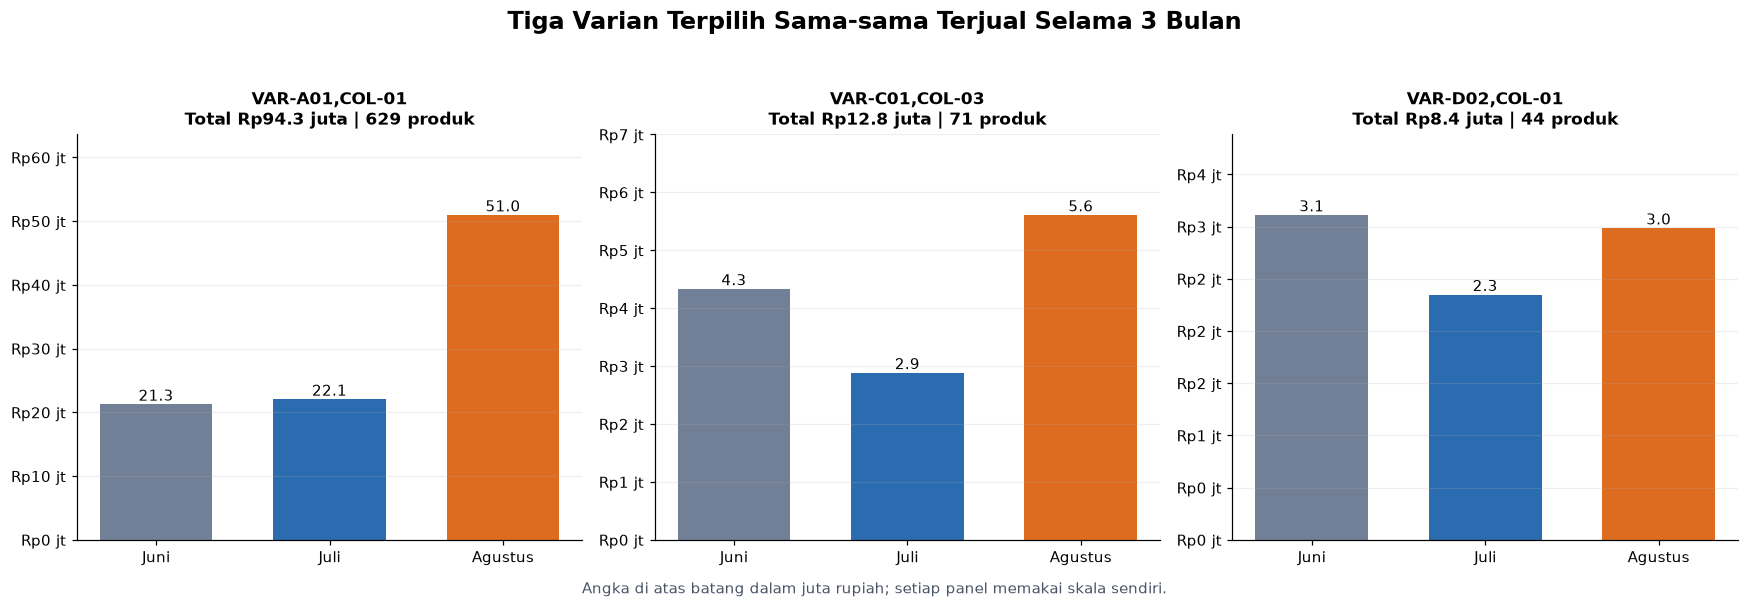

In [16]:
# Cell 16 - Memvisualisasikan performa bulanan rekomendasi
month_order = ["Juni", "Juli", "Agustus"]
month_colors = ["#718096", "#2B6CB0", "#DD6B20"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, variant_name in zip(axes, selected_names):
    values = (
        hmug_scored.loc[hmug_scored["varian"].eq(variant_name)]
        .set_index("bulan")
        .reindex(month_order)["penjualan_terkonfirmasi"]
    )
    bars = ax.bar(month_order, values, color=month_colors, width=0.65)
    selected_row = selected_variants.loc[selected_variants["varian"].eq(variant_name)].iloc[0]
    ax.set_title(
        f"{variant_name}\nTotal Rp{values.sum() / 1_000_000:.1f} juta | "
        f"{selected_row['produk_terkonfirmasi']:,.0f} produk",
        fontsize=11
    )
    ax.set_ylim(0, values.max() * 1.25)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"Rp{value / 1_000_000:.0f} jt"))
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value / 1_000_000:.1f}", ha="center", va="bottom")

fig.suptitle("Tiga Varian Terpilih Sama-sama Terjual Selama 3 Bulan", fontsize=16, fontweight="bold", y=1.04)
fig.text(0.5, -0.02, "Angka di atas batang dalam juta rupiah; setiap panel memakai skala sendiri.", ha="center", color="#4A5568")
plt.tight_layout()
plt.show()

<!-- document-notebook:managed:v1 anchor=27cd50f5 source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

### Cell 17: Memvisualisasikan perubahan konsentrasi

- **Tujuan Utama:** Mengomunikasikan perubahan komposisi HMUG dan pergantian SKU terbesar setelah split.
- **Input:** Komponen rekomendasi, residual HMUG, serta SKU terbesar sebelum dan sesudah dari Cell 10.
- **Output:** Stacked bar sebelum–sesudah dan perbandingan share listing terbesar.
- **Pesan Utama:** Grafik menjelaskan bahwa split memecah pencatatan omzet HMUG menjadi beberapa listing; judul secara eksplisit tidak mengklaim terciptanya penjualan baru.
- **Evidence Status:** SOURCE_OBSERVED; SAVED_OUTPUT berupa gambar historis.


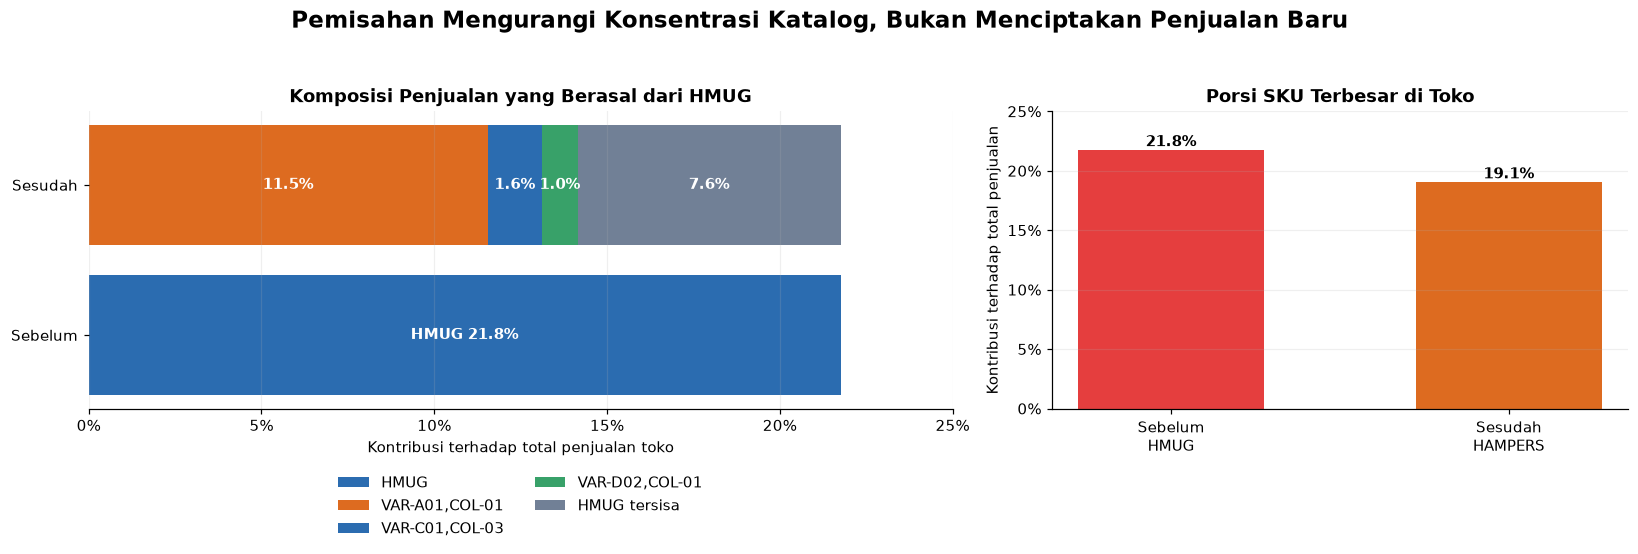

In [17]:
# Cell 17 - Memvisualisasikan perubahan konsentrasi katalog
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.5, 1]})
component_names = selected_names + ["HMUG tersisa"]
component_sales = selected_variants["penjualan_terkonfirmasi"].tolist() + [remaining_hmug]
component_shares = [value / store_total for value in component_sales]
component_colors = ["#DD6B20", "#2B6CB0", "#38A169", "#718096"]

axes[0].barh(["Sebelum"], [hmug_total / store_total], color="#2B6CB0", label="HMUG")
left = 0
for name, share, color in zip(component_names, component_shares, component_colors):
    axes[0].barh(["Sesudah"], [share], left=left, color=color, label=name)
    axes[0].text(left + share / 2, 1, f"{share:.1%}", ha="center", va="center", color="white", fontweight="bold")
    left += share
axes[0].text(hmug_total / store_total / 2, 0, f"HMUG {hmug_total / store_total:.1%}", ha="center", va="center", color="white", fontweight="bold")
axes[0].set_xlim(0, 0.25)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0%}"))
axes[0].set_title("Komposisi Penjualan yang Berasal dari HMUG")
axes[0].set_xlabel("Kontribusi terhadap total penjualan toko")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
axes[0].spines[["top", "right", "left"]].set_visible(False)
axes[0].grid(axis="x", alpha=0.2)

top_labels = [f"Sebelum\n{before_top['sku_induk']}", f"Sesudah\n{after_top['sku_induk']}"]
top_values = [before_top["share_store"], after_top["share_store"]]
bars = axes[1].bar(top_labels, top_values, color=["#E53E3E", "#DD6B20"], width=0.55)
axes[1].set_ylim(0, 0.25)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0%}"))
axes[1].set_title("Porsi SKU Terbesar di Toko")
axes[1].set_ylabel("Kontribusi terhadap total penjualan")
axes[1].grid(axis="y", alpha=0.2)
axes[1].spines[["top", "right"]].set_visible(False)
for bar, value in zip(bars, top_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value, f"{value:.1%}", ha="center", va="bottom", fontweight="bold")

fig.suptitle("Pemisahan Mengurangi Konsentrasi Katalog, Bukan Menciptakan Penjualan Baru", fontsize=15, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

<!-- document-notebook:managed:v1 anchor=fb0eb8b8 source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

## Fase 8 — Visualisasi pelengkap

### Cell 18: Membandingkan aktual dan run-rate

- **Tujuan Utama:** Menjelaskan mengapa angka Agustus tidak boleh dibandingkan langsung dengan bulan penuh.
- **Proses/Metode:** Batang biru menunjukkan omzet tercatat; segmen berarsir hanya menambahkan hari 29–31 menggunakan laju harian yang sama.
- **Output:** Bar chart aktual dan ekstrapolasi serta tabel ringkas `period_visual`.
- **Pesan Utama:** Agustus tercatat Rp251,2 juta sampai hari ke-28, dengan run-rate satu bulan Rp278,1 juta.
- **Batasan / Open Issue:** Arsiran merupakan normalisasi berbasis asumsi laju tetap, bukan forecast.
- **Evidence Status:** SOURCE_OBSERVED; belum ada SAVED_OUTPUT pada notebook sumber.


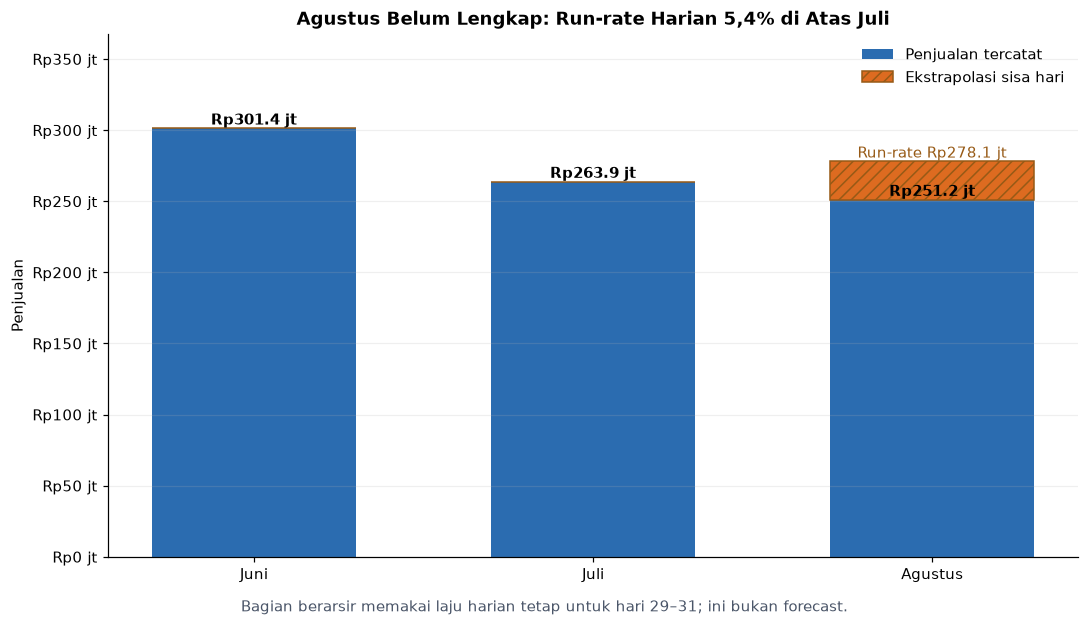

[Ringkasan Aktual dan Run-rate]


,bulan,status_periode,penjualan_tercatat,run_rate_satu_bulan
0,Juni,Bulan penuh,"Rp301,366,853","Rp301,366,853"
1,Juli,Bulan penuh,"Rp263,870,898","Rp263,870,898"
2,Agustus,Bulan parsial,"Rp251,212,191","Rp278,127,783"


In [18]:
# Cell 18 - Memvisualisasikan penjualan aktual dan run-rate
period_visual = period_audit.copy()
period_visual["tambahan_run_rate"] = (
    period_visual["run_rate_satu_bulan"]
    - period_visual["penjualan_tercatat"]
).clip(lower=0)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars_actual = ax.bar(
    period_visual["bulan"],
    period_visual["penjualan_tercatat"],
    color="#2B6CB0",
    width=0.6,
    label="Penjualan tercatat"
)
bars_extension = ax.bar(
    period_visual["bulan"],
    period_visual["tambahan_run_rate"],
    bottom=period_visual["penjualan_tercatat"],
    color="#DD6B20",
    edgecolor="#975A16",
    hatch="///",
    width=0.6,
    label="Ekstrapolasi sisa hari"
)

for actual_bar, extension_bar, row in zip(
    bars_actual,
    bars_extension,
    period_visual.itertuples()
):
    ax.text(
        actual_bar.get_x() + actual_bar.get_width() / 2,
        row.penjualan_tercatat,
        f"Rp{row.penjualan_tercatat / 1_000_000:.1f} jt",
        ha="center",
        va="bottom",
        fontweight="bold"
    )
    if row.tambahan_run_rate > 0:
        ax.text(
            extension_bar.get_x() + extension_bar.get_width() / 2,
            row.run_rate_satu_bulan,
            f"Run-rate Rp{row.run_rate_satu_bulan / 1_000_000:.1f} jt",
            ha="center",
            va="bottom",
            color="#975A16"
        )

ax.set_title("Agustus Belum Lengkap: Run-rate Harian 5,4% di Atas Juli")
ax.set_ylim(0, period_visual["run_rate_satu_bulan"].max() * 1.22)
ax.set_ylabel("Penjualan")
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"Rp{value / 1_000_000:.0f} jt")
)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper right")
fig.text(
    0.5,
    -0.02,
    "Bagian berarsir memakai laju harian tetap untuk hari 29–31; ini bukan forecast.",
    ha="center",
    color="#4A5568"
)
plt.tight_layout()
plt.show()

print("[Ringkasan Aktual dan Run-rate]")
display(
    period_visual[[
        "bulan",
        "status_periode",
        "penjualan_tercatat",
        "run_rate_satu_bulan"
    ]].style.format({
        "penjualan_tercatat": "Rp{:,.0f}",
        "run_rate_satu_bulan": "Rp{:,.0f}"
    })
)


<!-- document-notebook:managed:v1 anchor=2200ce15 source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

### Cell 19: Memvisualisasikan robustness kandidat

- **Tujuan Utama:** Merangkum enam pengujian ketahanan dalam satu matriks keputusan.
- **Proses/Metode:** Menggabungkan tiga skenario atribusi dan tiga leave-one-month-out fold; sel hijau berarti kandidat masuk tiga besar.
- **Output:** `robustness_matrix`, heatmap Top 3, dan `robustness_visual_summary`.
- **Pesan Utama:** A01 dan C01 konsisten pada seluruh pengujian; D02 kuat pada mayoritas pengujian, sedangkan A02 dan B03 hanya pada kondisi tertentu.
- **Batasan / Open Issue:** Frekuensi kelolosan bukan probabilitas keberhasilan atau bobot statistik.
- **Evidence Status:** SOURCE_OBSERVED; belum ada SAVED_OUTPUT pada notebook sumber.


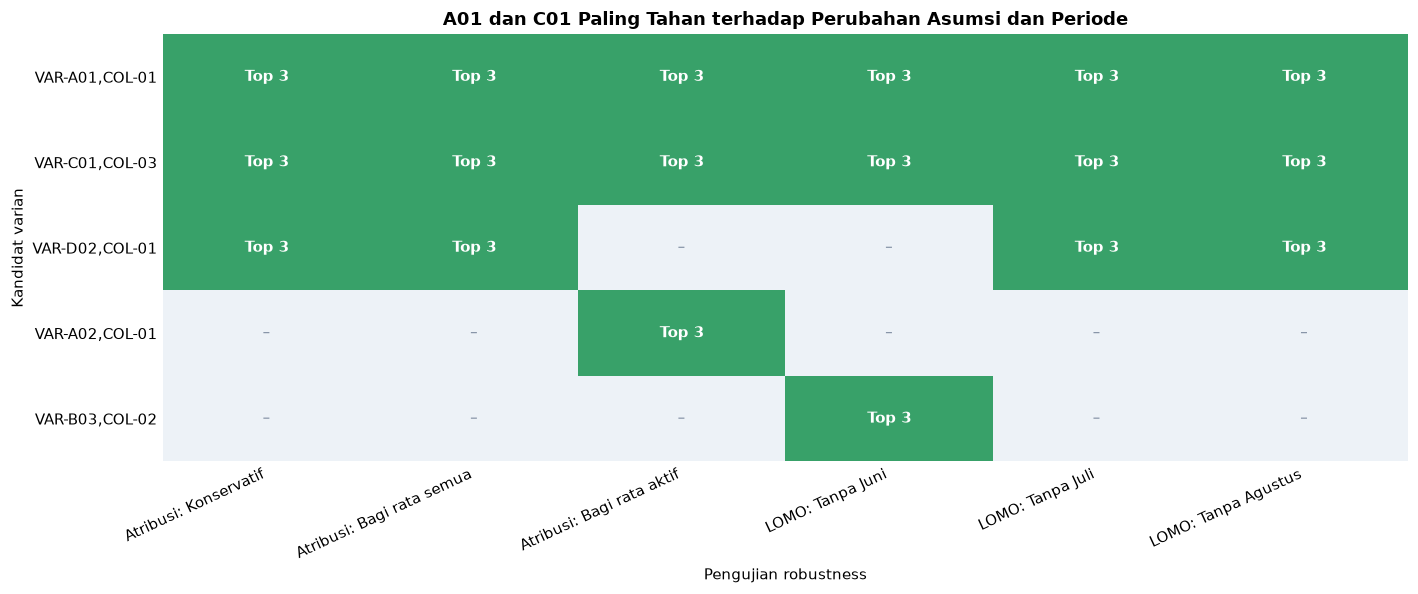

[Ringkasan Ketahanan Kandidat]


,varian,jumlah_lolos_top3,jumlah_pengujian,tingkat_kelolosan
0,"VAR-A01,COL-01",6,6,100%
1,"VAR-C01,COL-03",6,6,100%
2,"VAR-D02,COL-01",4,6,67%
3,"VAR-A02,COL-01",1,6,17%
4,"VAR-B03,COL-02",1,6,17%


Catatan: enam pengujian menjawab dua sumber ketidakpastian berbeda. Tingkat kelolosan bukan probabilitas keberhasilan bisnis.


In [19]:
# Cell 19 - Memvisualisasikan ketahanan kandidat
from matplotlib.colors import ListedColormap

scenario_test_names = {
    "Konservatif": "Atribusi: Konservatif",
    "Bagi rata semua varian": "Atribusi: Bagi rata semua",
    "Bagi rata varian aktif": "Atribusi: Bagi rata aktif"
}
lomo_test_names = {
    "Tanpa Juni": "LOMO: Tanpa Juni",
    "Tanpa Juli": "LOMO: Tanpa Juli",
    "Tanpa Agustus": "LOMO: Tanpa Agustus"
}

robustness_long = pd.concat([
    scenario_top3[["varian", "skenario"]]
    .assign(test=lambda frame: frame["skenario"].map(scenario_test_names))
    [["varian", "test"]],
    lomo_top3[["varian", "fold"]]
    .assign(test=lambda frame: frame["fold"].map(lomo_test_names))
    [["varian", "test"]]
], ignore_index=True).drop_duplicates()

test_order = list(scenario_test_names.values()) + list(lomo_test_names.values())
candidate_order = selected_names + sorted(
    set(robustness_long["varian"]) - set(selected_names)
)
robustness_matrix = (
    robustness_long.assign(masuk_top3=1)
    .pivot(index="varian", columns="test", values="masuk_top3")
    .reindex(index=candidate_order, columns=test_order)
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.imshow(
    robustness_matrix,
    cmap=ListedColormap(["#EDF2F7", "#38A169"]),
    vmin=0,
    vmax=1,
    aspect="auto"
)

for row_index, variant_name in enumerate(robustness_matrix.index):
    for column_index, test_name in enumerate(robustness_matrix.columns):
        passed = robustness_matrix.loc[variant_name, test_name]
        ax.text(
            column_index,
            row_index,
            "Top 3" if passed else "–",
            ha="center",
            va="center",
            color="white" if passed else "#718096",
            fontweight="bold" if passed else "normal"
        )

ax.set_xticks(range(len(robustness_matrix.columns)))
ax.set_xticklabels(robustness_matrix.columns, rotation=25, ha="right")
ax.set_yticks(range(len(robustness_matrix.index)))
ax.set_yticklabels(robustness_matrix.index)
ax.set_title("A01 dan C01 Paling Tahan terhadap Perubahan Asumsi dan Periode")
ax.set_xlabel("Pengujian robustness")
ax.set_ylabel("Kandidat varian")
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

robustness_visual_summary = pd.DataFrame({
    "varian": robustness_matrix.index,
    "jumlah_lolos_top3": robustness_matrix.sum(axis=1).values,
    "jumlah_pengujian": robustness_matrix.shape[1]
})
robustness_visual_summary["tingkat_kelolosan"] = (
    robustness_visual_summary["jumlah_lolos_top3"]
    / robustness_visual_summary["jumlah_pengujian"]
)

print("[Ringkasan Ketahanan Kandidat]")
display(
    robustness_visual_summary.style.format({
        "tingkat_kelolosan": "{:.0%}"
    })
)
print(
    "Catatan: enam pengujian menjawab dua sumber ketidakpastian berbeda. "
    "Tingkat kelolosan bukan probabilitas keberhasilan bisnis."
)


<!-- document-notebook:managed:v1 anchor=1523f079 source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

### Cell 20: Memvisualisasikan konsentrasi internal

- **Tujuan Utama:** Menunjukkan bahwa tiga SKU rekomendasi masih bergantung pada A01.
- **Proses/Metode:** Membuat 100% stacked horizontal bar dari share omzet bulanan A01, C01, dan D02.
- **Output:** Grafik komposisi tiga bulan dan tabel `monthly_portfolio_concentration`.
- **Pesan Utama:** Share A01 naik dari 74,1% pada Juni menjadi 85,6% pada data Agustus sampai tanggal 28.
- **Keputusan:** Split memperbaiki struktur katalog, tetapi tidak boleh dipresentasikan sebagai diversifikasi permintaan yang sudah selesai.
- **Evidence Status:** SOURCE_OBSERVED; belum ada SAVED_OUTPUT pada notebook sumber.


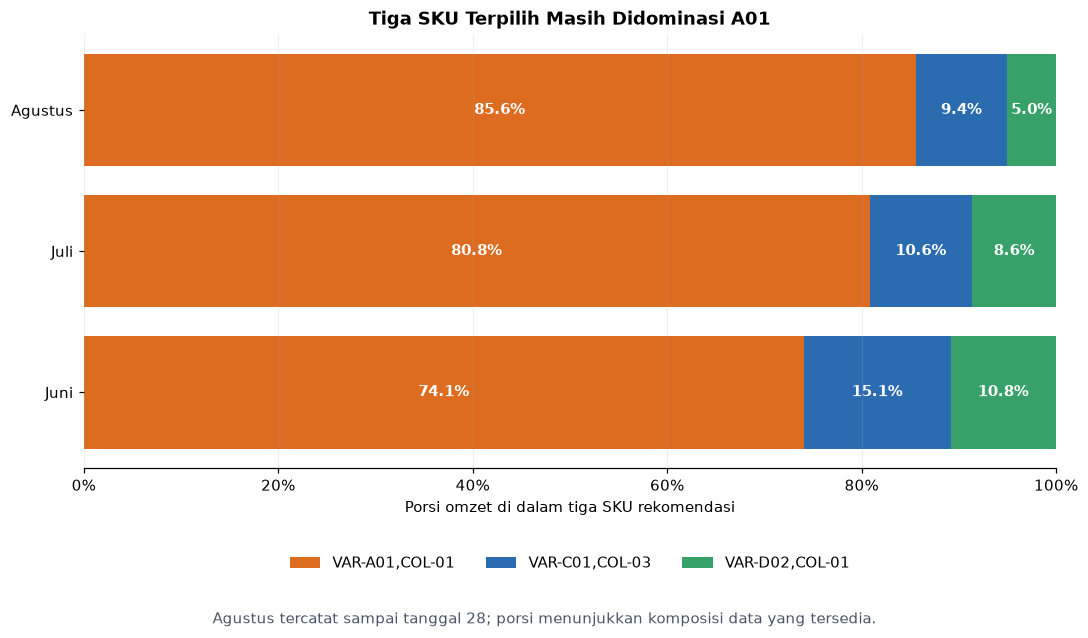

[Konsentrasi Internal Bulanan]


,bulan,penjualan_tiga_sku,sku_terbesar,porsi_sku_terbesar,hhi_internal
0,Juni,"Rp28,713,208","VAR-A01,COL-01",74.1%,"5,831.7"
1,Juli,"Rp27,291,220","VAR-A01,COL-01",80.8%,"6,717.7"
2,Agustus,"Rp59,567,468","VAR-A01,COL-01",85.6%,"7,436.1"


In [20]:
# Cell 20 - Memvisualisasikan konsentrasi internal bulanan
variant_colors = {
    "VAR-A01,COL-01": "#DD6B20",
    "VAR-C01,COL-03": "#2B6CB0",
    "VAR-D02,COL-01": "#38A169"
}

fig, ax = plt.subplots(figsize=(10, 5.5))
left = np.zeros(len(selected_monthly_shares))

for variant_name in selected_names:
    shares = selected_monthly_shares[variant_name].to_numpy()
    bars = ax.barh(
        selected_monthly_shares.index,
        shares,
        left=left,
        color=variant_colors[variant_name],
        label=variant_name
    )
    for bar, share, start in zip(bars, shares, left):
        if share >= 0.05:
            ax.text(
                start + share / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{share:.1%}",
                ha="center",
                va="center",
                color="white",
                fontweight="bold"
            )
    left += shares

ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.set_xlabel("Porsi omzet di dalam tiga SKU rekomendasi")
ax.set_title("Tiga SKU Terpilih Masih Didominasi A01")
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.17),
    ncol=3,
    frameon=False
)
fig.text(
    0.5,
    -0.04,
    "Agustus tercatat sampai tanggal 28; porsi menunjukkan komposisi data yang tersedia.",
    ha="center",
    color="#4A5568"
)
plt.tight_layout()
plt.show()

print("[Konsentrasi Internal Bulanan]")
display(
    monthly_portfolio_concentration[[
        "bulan",
        "penjualan_tiga_sku",
        "sku_terbesar",
        "porsi_sku_terbesar",
        "hhi_internal"
    ]].style.format({
        "penjualan_tiga_sku": "Rp{:,.0f}",
        "porsi_sku_terbesar": "{:.1%}",
        "hhi_internal": "{:,.1f}"
    })
)


<!-- document-notebook:managed:v1 anchor=6e8d2067 source_sha256=0c471f08f1dad41bc041d1e8753ded32d5907d78a0e2e32ed9cbd4d7c247222d -->

## Fase 9 — Quality assurance akhir

### Cell 21: Memvalidasi seluruh pipeline

- **Tujuan Utama:** Menggabungkan gate rekomendasi dengan pemeriksaan periode parsial, LOMO, HHI, konsentrasi internal, what-if, ASP, dan kebutuhan data margin.
- **Input:** Seluruh objek validasi utama dari Cells 03–15.
- **Proses/Metode:** Menjalankan pemeriksaan boolean dan menghentikan pipeline melalui assertion jika satu saja gagal.
- **Output:** `extended_checks` dan status akhir.
- **Validasi:** Kode memeriksa 29 kondisi, termasuk konservasi total, tepat tiga kandidat per skenario/fold, rumus ASP, dan skenario nol.
- **Evidence Status:** SOURCE_OBSERVED. Cell ini belum memiliki saved output atau execution count pada notebook sumber; jalankan ulang notebook dari atas untuk merekam hasil final di Jupyter.


In [21]:
# Cell 21 - Memvalidasi seluruh analisis
zero_scenario = uplift_scenarios.loc[
    uplift_scenarios["asumsi_perubahan"].eq(0)
].iloc[0]

required_margin_data = {
    "Penjualan bersih",
    "COGS per produk",
    "Marketplace fee",
    "Subsidi pengiriman",
    "Biaya packaging",
    "Biaya iklan per SKU"
}

extended_checks = {
    **checks,
    "Agustus dikenali sebagai bulan parsial":
        period_audit.loc[
            period_audit["bulan"].eq("Agustus"), "status_periode"
        ].eq("Bulan parsial").all(),
    "Total bulanan audit cocok dengan ringkasan toko":
        np.allclose(period_audit["penjualan_tercatat"], reported_store_monthly, atol=1),
    "LOMO menguji tepat tiga fold":
        lomo_top3["fold"].nunique() == 3,
    "Setiap fold LOMO memilih tepat tiga kandidat":
        lomo_top3.groupby("fold")["varian"].nunique().eq(3).all(),
    "Dua kandidat utama tahan pada seluruh fold LOMO":
        selected_lomo_summary.set_index("varian")["jumlah_masuk_tiga_besar"]
        .reindex(["VAR-A01,COL-01", "VAR-C01,COL-03"])
        .eq(3).all(),
    "Kandidat ketiga tahan pada mayoritas fold LOMO":
        selected_lomo_summary.set_index("varian")
        .loc["VAR-D02,COL-01", "jumlah_masuk_tiga_besar"] >= 2,
    "HHI turun pada seluruh skenario":
        hhi_comparison["hhi_sesudah"].lt(hhi_comparison["hhi_sebelum"]).all(),
    "HHI diuji pada tiga skenario atribusi":
        hhi_comparison["skenario"].nunique() == 3,
    "Setiap skenario HHI memilih tepat tiga SKU":
        scenario_top3.groupby("skenario")["varian"].nunique().eq(3).all(),
    "Total portofolio rekomendasi konsisten":
        np.isclose(portfolio_total, selected_total, atol=1),
    "Porsi internal portofolio berjumlah seratus persen":
        np.isclose(
            portfolio_variant_summary["porsi_dalam_tiga_sku"].sum(),
            1,
            atol=1e-9
        ),
    "What-if tanpa uplift mempertahankan total toko":
        np.isclose(zero_scenario["total_toko_skenario"], store_total, atol=1),
    "What-if tanpa uplift mempertahankan omzet tiga SKU":
        np.isclose(
            zero_scenario["penjualan_tiga_sku_skenario"],
            selected_total,
            atol=1
        ),
    "Semua total toko pada what-if dihitung konsisten":
        np.isclose(
            uplift_scenarios["total_toko_skenario"],
            store_total + uplift_scenarios["perubahan_penjualan"],
            atol=1
        ).all(),
    "What-if memiliki skenario downside dan upside":
        uplift_scenarios["asumsi_perubahan"].lt(0).any()
        and uplift_scenarios["asumsi_perubahan"].gt(0).any(),
    "ASP seluruh rekomendasi bernilai positif":
        asp_table["asp"].gt(0).all(),
    "ASP dihitung sebagai penjualan dibagi produk":
        np.isclose(
            asp_table["asp"],
            asp_table["penjualan_terkonfirmasi"]
            / asp_table["produk_terkonfirmasi"],
            atol=1e-9
        ).all(),
    "Kebutuhan data margin tercatat lengkap":
        set(margin_requirements["data_tambahan"]) == required_margin_data
}

extended_failures = [
    name for name, passed in extended_checks.items() if not passed
]

print("[Extended Final Quality Assurance]")
for name, passed in extended_checks.items():
    print(f"{'LULUS' if passed else 'GAGAL'} - {name}")

assert not extended_failures, (
    "QA akhir gagal: " + ", ".join(extended_failures)
)

print()
print("STATUS AKHIR: LULUS")
print(
    "Integritas data, ranking, sensitivity analysis, normalisasi periode, "
    "LOMO, HHI, konsentrasi internal, what-if, ASP, dan batasan margin "
    "telah tervalidasi."
)


[Extended Final Quality Assurance]
LULUS - Tidak ada kegagalan kualitas data yang blocking
LULUS - Anomali mentah hanya terjadi pada HMUG
LULUS - Deduplikasi HMUG cocok untuk setiap bulan
LULUS - Tepat tiga varian dipilih
LULUS - Semua rekomendasi berstatus Normal
LULUS - Semua omzet rekomendasi terkonfirmasi
LULUS - Semua rekomendasi terjual selama tiga bulan
LULUS - Semua rekomendasi masuk tiga besar pada empat metrik
LULUS - Dua kandidat utama menang pada semua skenario
LULUS - Kandidat ketiga menang pada mayoritas skenario
LULUS - Pemisahan tidak mengubah total HMUG
LULUS - Nama rekomendasi sesuai keputusan
LULUS - Agustus dikenali sebagai bulan parsial
LULUS - Total bulanan audit cocok dengan ringkasan toko
LULUS - LOMO menguji tepat tiga fold
LULUS - Setiap fold LOMO memilih tepat tiga kandidat
LULUS - Dua kandidat utama tahan pada seluruh fold LOMO
LULUS - Kandidat ketiga tahan pada mayoritas fold LOMO
LULUS - HHI turun pada seluruh skenario
LULUS - HHI diuji pada tiga skenario 